# Partículas elementales: laboratorios 2025/2026

## Práctica 2: física del Higgs

_Clara Álvarez Luna, Dpto. Física Teórica, <c.a.luna@ucm.es>_

_Patricia Andrea Gutiérrez García, Dpto. Física Teórica, <patricgu@ucm.es>_

_Javier Martínez Martín, Dpto. Física Teórica, <javmar21@ucm.es>_

Nombre: Germán Cousillas Martínez

Grupo laboratorio: L4

Grupo teoría: A

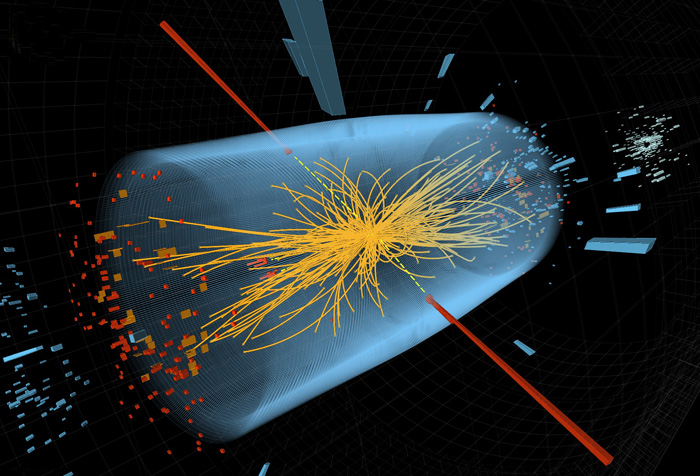

### Resumen

<font size="3">

En esta práctica estudiaremos algunas propiedades interesantes de la física relacionada con el bosón de Higgs. En concreto, se calculará la desintegración de dicho bosón en disitintos canales relevantes, y cómo dependen éstos de la masa del Higgs. Finalmente se verá, para la masa medida del bosón cuáles son los canales más relevantes en los que se desintegra.


__Índice__
- Introducción
- Desintegración del Higgs a _tree level_
- Desintegración del Higgs en partículas no masivas
- Anchura total de desintegración y _branching ratio_
- Conclusiones
- Referencias

# Introducción

<font size="3">

El 4 de julio de 2012 fueron presentados los resultados preliminares del CERN en los que se aparecía un exceso de eventos sobre el fondo esperado, con una significancia estadísitica de $5 \sigma$, indicando un bosón de masa en torno a 125 GeV. Este descubrimiento fue anunciado en el CERN basándose en los datos tomados por los principales experimentos del LHC, ATLAS y CMS. La importancia de esta observación es que es consistente con las predicciones del llamado _bosón de Higgs_ del Modelo Estándar, única partícula de dicho modelo que faltaba por ser detectada experimentalmente. Nótese que, aunque estemos seguros de la masa de esta resonancia, todavía resulta necesario seguir investigando las propiedades de esta partícula para poder asegurar que se trate exactamente de dicho bosón, o si tiene algunas propiedades ligeramente distintas, por ejemplo, estudiadas en algunos modelos de física más allá del Modelo Estándar (BSM). Además, conocer en detalle las propiedades de esta partícula resulta necesario para el estudio de muchos modelos en los que influye, como en los que tratan de explicar la materia oscura. 

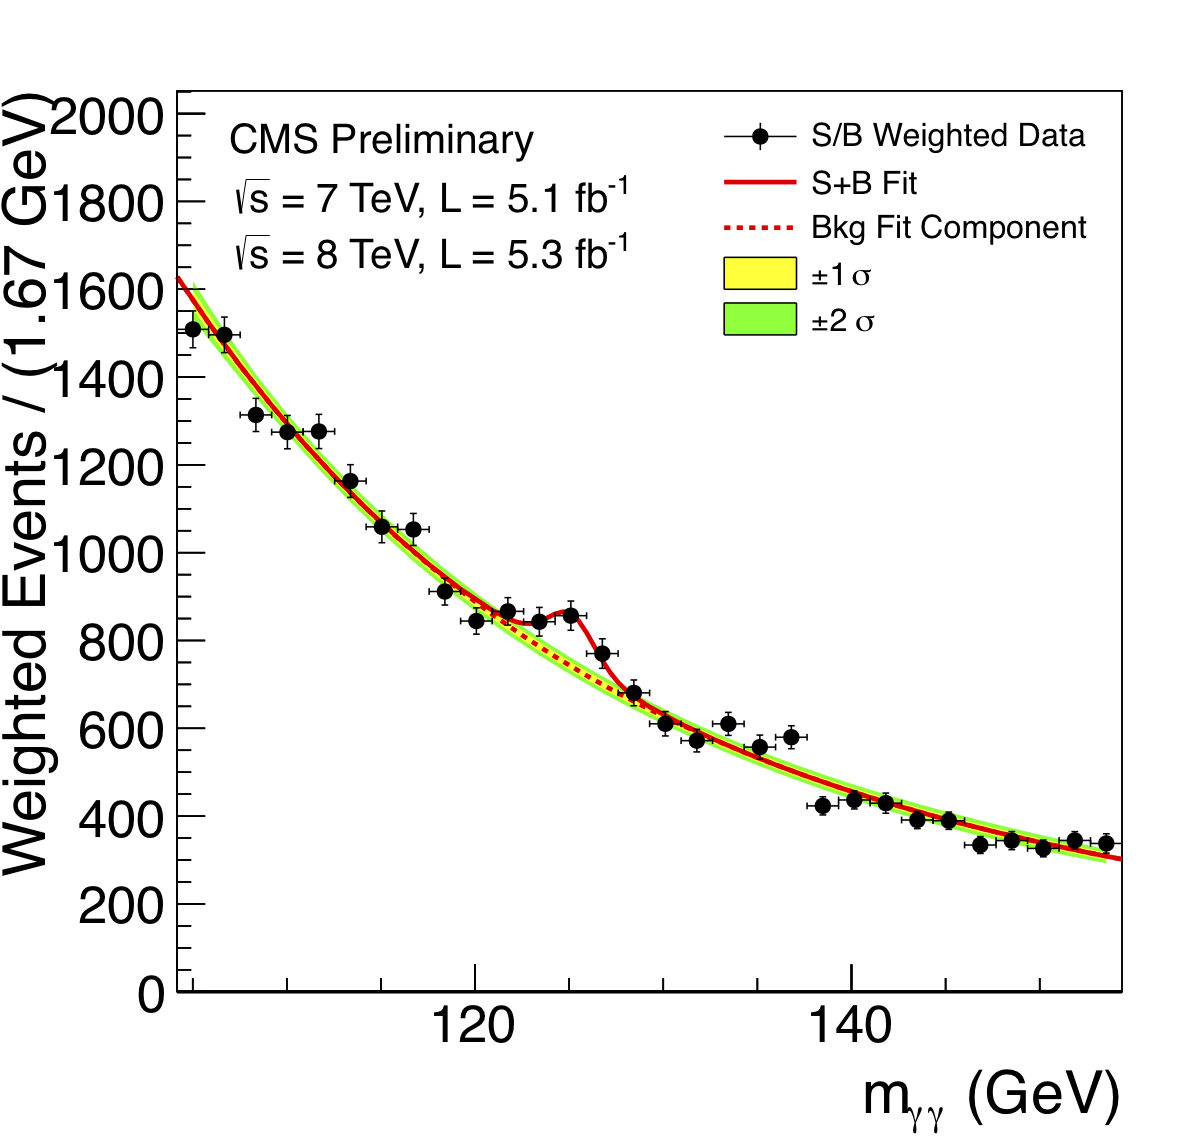


Un importante estudio a realizar con el Higgs es analizar cómo se desintegra en diferentes partículas. Como puede interaccionar con muchas partículas distintas, pueden haber múltiples procesos de desintegración, que llamaremos canales, sucediendo con distintas probabilidades, que llamaremos _branching ratios_. Cada canal vendrá dado por unas expresiones que dependerán de las partículas involucradas, sus masas, acoplamientos, etc. Finalmente, la anchura total de desintegración vendrá dada por la suma de todos los distintos canales.

En esta práctica tomaremos la masa del bosón de Higgs como un parámetro, y trataremos de estudiar otras propiedades del mismo, como los principales canales de desintegración. Se organizará como sigue. En primer lugar se estudiarán las desintegraciones a _tree level_: en un par fermión-antifermión, y en bosones W o Z. En segundo lugar se estudiarán las desintegraciones del Higgs en partículas sin masa: en un par de gluones o de fotones, o bien en un par fotón-Z. Por último se calculará la anchura total de desintegración y cómo depende ésta de los distintos canales estudiados (_branching ratios_), en función de la masa del Higgs. Se analizará, para el caso real del bosón descubierto en el LHC, qué canales son los más relevantes.

Nota: en esta práctica partiremos de las expresiones más sencillas para las desintegraciones, es decir, los diagramas de orden más bajo que contribuyen a las mismas. Para obtener expresiones más correctas sería necesario incluir órdenes mayores (_loops_) que nos darían un resultado mejor. Esto implica que pueden aparecer algunos puntos conflictivos en las funciones utilizadas, o bien que éstas no den un resultado numérico del todo exacto. Sin embargo, con estas expresiones podremos trabajar mucho mejor y nos darán un resultado aceptable, pudiéndonos hacer una buena idea del comportamiento general de las desintegraciones. Nótese que además en estos cálculos influyen muchos valores (masas, acoplamientos, etc.) que tienen también incertidumbres que deberían ser tomadas en cuenta para obtener un resultado numérico más exacto. 

Nota2: algunas de las funciones empleadas en la práctica son un poco complicadas, y hay que evaluarlas en arrays de muchos valores. Cuidado si le pedimos a _SymPy_ que nos las muestre todas por pantalla simultáneamente porque la ejecución del programa puede volverse muy lenta. 

<font size="3">

__Masas de las partículas del Modelo Estándar__

Quarks:

$m_u = 2.16$ MeV

$m_d = 4.67$ MeV

$m_s = 93$ MeV

$m_c = 1.27$ GeV

$m_b = 4.18$ GeV

$m_t = 173$ GeV

Leptones:

$m_e = 0.511$ MeV

$m_\mu = 105$ MeV

$m_\tau = 1.78$ GeV

$m_\nu\ \lesssim$ eV

Bosones:

$m_\gamma \sim 0$

$m_g = 0$

$m_W = 80.4$ GeV

$m_Z = 91.2$ GeV

$m_H = 125.1$ GeV

In [1]:
# Importación de librerías necesarias para la práctica:
# (véase la práctica 0 si se tienen dudas sobre estas librerías)

from sympy import *
init_printing()

import numpy as np

import matplotlib as Çmpl 
import matplotlib.pyplot as plt
from matplotlib import rc
#plt.rc('text', usetex=True)
#plt.rc('font', familiy='serif')
%matplotlib inline

import time
start_time = time.time()

_Nota: con init_printing() indicamos a python que nos muestre las expresiones matemáticas en un formato visualmente más útil para nosotros. Sin embargo, esto suele llevarle bastante tiempo, sobre todo en el caso de arrays largos, por lo que no es recomendable decirle que nos muestre todos los pasos intermedios a la vez; podéis ir descomentando las líneas que queráis ver para comprobarlas._

In [2]:
# Valores de las masas: [m] = GeV

m_u, m_d, m_s, m_c, m_b, m_t, m_e, m_mu, m_tau, m_nu, m_gamma, m_g, m_W, m_Z, m_H = symbols( 
    'm_u, m_d, m_s, m_c, m_b, m_t, m_e, m_mu, m_tau, m_nu, m_gamma, m_g, m_W, m_Z, m_H', real=True)

valores_masas = [(m_u, 2.16 * 10 ** -3), (m_d, 4.67 * 10 ** -3), (m_s, 93 * 10 ** -3), (m_c, 1.27), (m_b, 4.18), (m_t, 173), 
                 (m_e, 0.511 * 10 ** -3), (m_mu, 105 * 10 ** -3), (m_tau, 1.78), (m_nu, 0), 
                 (m_gamma, 0), (m_g, 0), (m_W, 80.4), (m_Z, 91.2)
                 #, (m_H, 125.1)
                ]

m_u, m_d, m_s, m_c, m_b, m_t, m_e, m_mu, m_tau, m_nu, m_gamma, m_g, m_W, m_Z, m_H

In [3]:
# Otros valores: [E] = GeV

N_C, v, theta_W, G_F, alpha, alpha_S, m_f, m_gauge = symbols('N_C v theta_W G_F alpha alpha_S m_f m_gauge', real=True)

valores = [(v, 246), (theta_W, np.arcsin(np.sqrt(0.231))), (G_F, 1.166 * 10 ** -5), (alpha, 7.3 * 10 ** -3), (alpha_S, 0.1181)]

N_C, v, theta_W, G_F, alpha, alpha_S, m_f, m_gauge

In [4]:
# Ángulo de Weinberg
np.round(np.degrees(np.arcsin(np.sqrt(0.231))), 2)

# Desintegraciones del Higgs a _tree level_

## Desintegración en un par fermión - antifermión

<font size="3">

En esta sección estudiaremos la desintegración del Higgs en un par de fermiones: $H \to f\bar{f}$. Veremos que ésta depende de la masa del fermión considerado, por lo que será relevante para los más masivos, concretamente los quarks _top, bottom_ y _charm_ ($t, b, c$) y el leptón tau ($\tau$).
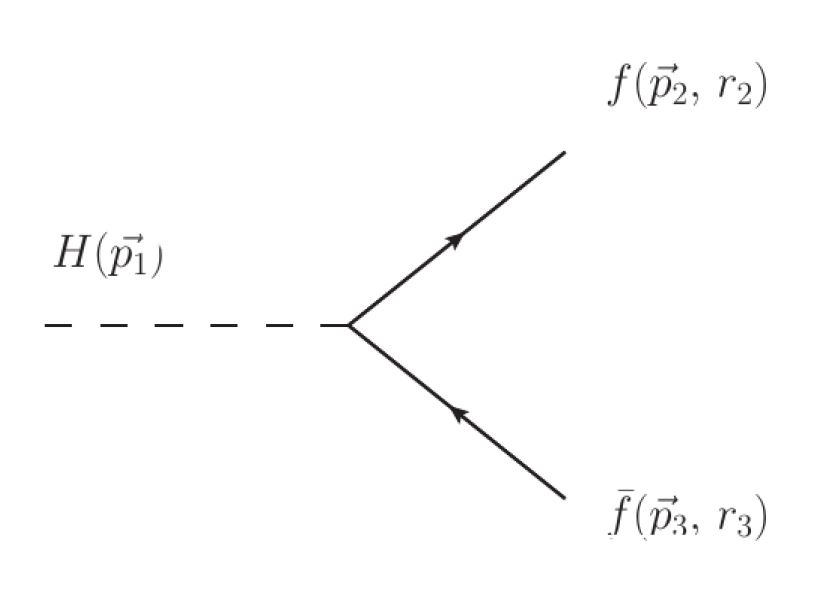


La desintegración del Higgs en fermiones, reflejada en el diagrama de la figura, viene dada por la siguiente expresión

$$ \Gamma (H\to f\bar{f}) = N_c \frac{m_f^2}{8\pi\nu^2} m_H \left(1 - \frac{4 m_f^2}{m_H^2}\right)^{3/2}\ , $$

donde $N_c$ es el número de colores ($N_c=1$ para leptones y $N_c=3$ para quarks), y $v$ es el valor de expectación en el vacío para el campo de Higgs 

$$v = \frac{1}{(\sqrt{2} G_F)^{1/2}} \simeq 246\ {\rm GeV}\ , $$ 

siendo $G_F \simeq 1.166 \cdot 10^{-5}\ {\rm GeV}^{-2}$ la constante de Fermi. Como vemos, la expresión dada depende de la masa de las partículas finales, por lo que serán más probables las desintegraciones a partículas de mayor masa. No obstante, debemos ver que para la más masiva, que es el quark _top_ este resultado sólo será válido cuando la masa del Higgs sea mayor de dos veces su masa ($m_H > 346$ GeV), ya que si no la desintegración se daría mediante partículas virtuales (lo que daría una probabilidad mucho menor que no vamos a tratar). Esto no sucede para los demás fermiones tratados pues su masa es muy inferior, pero sí lo tendremos en cuenta en la desintegración en bosones gauge (véase el próximo apartado).


Esta expresión es sencilla por lo que la definiremos de forma simbólica con _SymPy_ y sustituiremos los valores de cada fermión. Dejaremos la masa del Higgs como parámetro libre para poder estudiar cómo dependen estas desintegraciones de la misma. A continuación, para poder representarlo gráficamente evaluaremos estas funciones en un array de masas y finalmente las representaremos con _Matplotlib_.

_Nota: para masas altas, la desintegración del top se hace muy dominante, por lo que para representarla junto a las otras es recomendable dividirla entre un factor para que se distingan todas._

In [6]:
# Definimos la anchura parcial para esta desintegración:

Gamma_ff = symbols('Gamma_ff', cls=Function)

Gamma_ff = N_C * (m_f ** 2) * m_H / (8 * pi * v ** 2) * (1 - 4 * (m_f ** 2) / (m_H ** 2)) ** (3 / 2)

#Gamma_ff

In [7]:
# Calculamos para cada fermión a tener en cuenta: t, b, c, tau
# Completar. Cuidado con el número de colores correspondiente a cada partícula.

Gamma_tt, Gamma_bb, Gamma_cc, Gamma_tautau = symbols('Gamma_tt, Gamma_bb, Gamma_cc, Gamma_tautau', cls=Function)

Gamma_tt = Gamma_ff.subs(N_C, 3).subs(m_f, m_t)
Gamma_bb = Gamma_ff.subs(N_C, 3).subs(m_f, m_b)
Gamma_cc = Gamma_ff.subs(N_C, 3).subs(m_f, m_c)
Gamma_tautau = Gamma_ff.subs(N_C, 1).subs(m_f, m_tau)

In [7]:
#Gamma_tt.subs(valores_masas).subs(valores)

In [8]:
# Primer intento de plots: [m] = GeV
# Completar.

rango_masas = np.linspace(7 * 10 ** 1, 10 ** 3, 10 ** 3)

Gamma_tt_m = lambdify( m_H, Gamma_tt.subs(valores_masas).subs(valores), "numpy" )
Gamma_bb_m = lambdify( m_H, Gamma_bb.subs(valores_masas).subs(valores), "numpy" )
Gamma_cc_m = lambdify( m_H, Gamma_cc.subs(valores_masas).subs(valores), "numpy" )
Gamma_tautau_m = lambdify( m_H, Gamma_tautau.subs(valores_masas).subs(valores), "numpy" )

# Gamma_tt_m tiene valores NaN, por lo que hay que quitárselos para que no dé error al representar
Gamma_tt_tot = np.nan_to_num(Gamma_tt_m(rango_masas)) # quitamos los valores NaN, SÓLO para Gamma_tt_m, las demás no tienen NaN

#Gamma_tt_m    # véase que en esta definición ya se ha incluido la evaluación en (rango_masas)
Gamma_bb_tot =  Gamma_bb_m(rango_masas)  # las demás funciones han de ser evaluadas para pasarlas a un array numérico
Gamma_cc_tot = Gamma_cc_m(rango_masas)
Gamma_tautau_tot = Gamma_tautau_m(rango_masas)

<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in power
  return (29929/161376)*m_H*(1 - 119716/m_H**2)**1.5/pi


_Nota: para esta práctica, debido a que las funciones representadas abarcan varios órdenes de magnitud, usaremos una representación logarítmica en el eje vertical en todos los casos. En el caso de matplotlib, se fija primero la escala logarítmica y después se realizan los plots correspondientes (si se hace al revés, genera un plot lineal y luego lo amplía, obteniendo una visualización inapropiada)._

Text(0.5, 1.0, 'Decay rates del bosón de Higgs a varios pares fermión-antifermión')

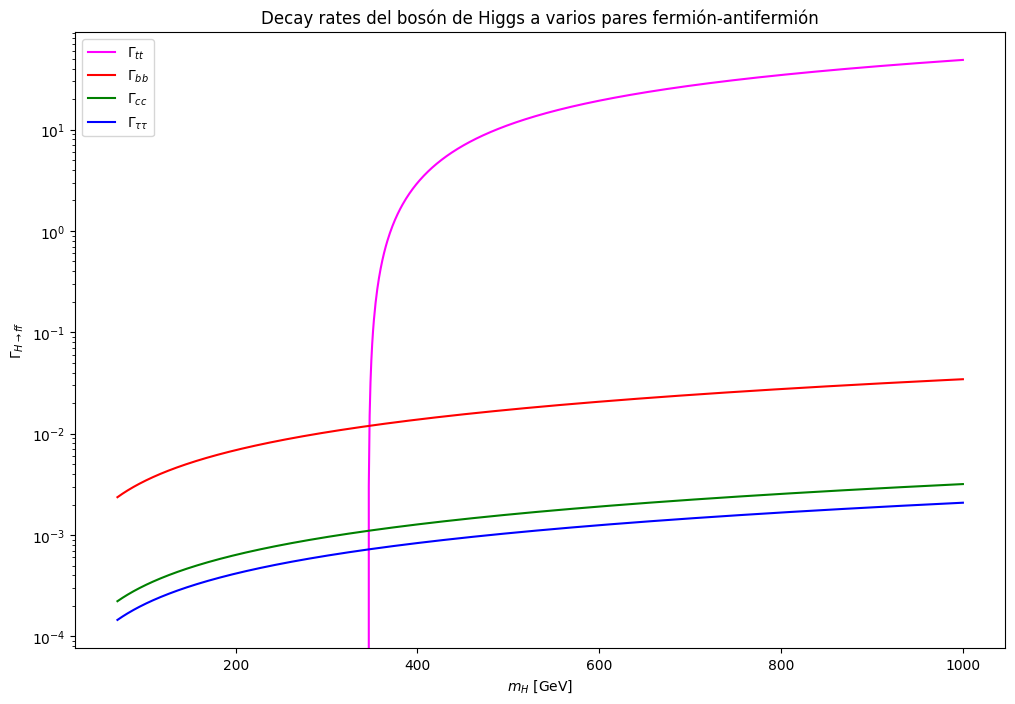

In [10]:
# Creamos un plot:
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...)

fig, ax = plt.subplots(1, figsize=(12,8))
ax.set_yscale("log")

ax.plot(rango_masas, Gamma_tt_tot, 'fuchsia', label=r'$\Gamma_{tt}$') 
ax.plot(rango_masas, Gamma_bb_tot, 'r', label=r'$\Gamma_{bb}$')
ax.plot(rango_masas, Gamma_cc_tot, 'g', label=r'$\Gamma_{cc}$')
ax.plot(rango_masas, Gamma_tautau_tot, 'b', label=r'$\Gamma_{\tau\tau}$')
ax.legend()
ax.set_xlabel(r"$m_H$" + " [GeV]")
ax.set_ylabel(r"$\Gamma_{H\to ff}$")
ax.set_title("Decay rates del bosón de Higgs a varios pares fermión-antifermión")


## Desintegración en un par de bosones gauge

<font size="3">

En esta sección estudiaremos la desintegración del Higgs en un par de bosones gauge, es decir $H \to WW, H \to ZZ$. Nótese que para que se produzca una desintegración de este tipo, la masa del Higgs deberá ser más del doble de la masa de los bosones gauge. Si no es así, la desintegración tendrá que darse obligatoriamente a través de partículas virtuales.

Como vemos, en este caso el análisis es un poco más complicado. Tendremos dos rangos de masas en los que las expresiones serán diferentes. En primer lugar analizaremos la desintegración en dos partículas reales, si el Higgs tuviera una masa muy grande, y en segundo lugar analizaremos el caso de las partículas virtuales (que como veremos, será el caso real para la masa medida del Higgs). Si el Higgs tuviera menos masa que estos bosones, estas desintegraciones no se darían. 

Las expresiones para el _W_ y el _Z_ son ligeramente distintas (además de los valores de sus masas). Para el caso de partículas reales el _Z_ debe incluir un factor $1/2$ adicional al tratarse de dos partículas idénticas (nótese que para el _W_ es $W^+ W^-$). Para el caso de partículas virtuales, el _Z_ debe incluir una serie de términos que vienen de ciertos elementos de matriz en los que aparece el ángulo de Weinberg. 

Para la desintegración en dos cuerpos, partículas reales: 

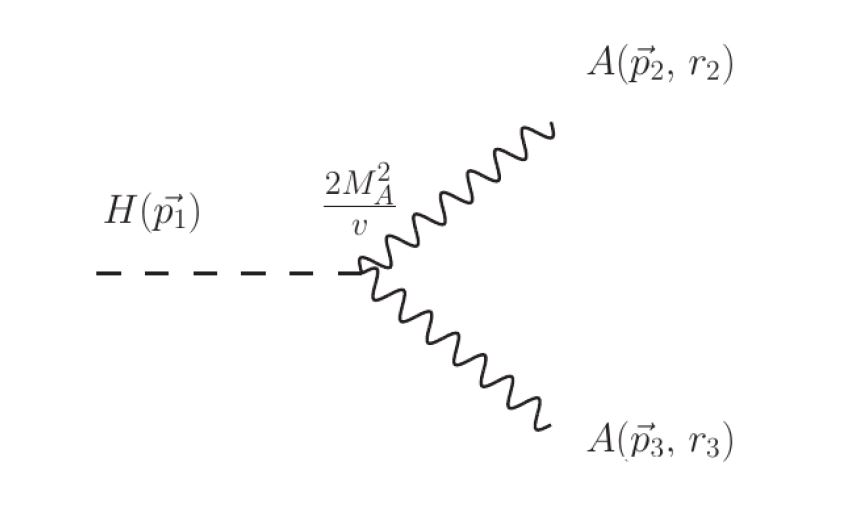

$$ \Gamma(H \to WW) = \frac{1}{4\pi} \frac{m_W^4}{m_H v^2} \left(1 - \frac{4 m_W^2}{m_H^2}\right) ^{1/2} \left(3 + \frac{m_H^4}{4 m_W^4} - \frac{m_H^2}{m_W^2}\right)\ , $$

$$ \Gamma(H \to ZZ) = \frac{1}{8\pi} \frac{m_Z^4}{m_H v^2} \left(1 - \frac{4 m_Z^2}{m_H^2}\right) ^{1/2} \left(3 + \frac{m_H^4}{4 m_Z^4} - \frac{m_H^2}{m_Z^2}\right)\ . $$



Para la desintegración en tres cuerpos, partículas virtuales:
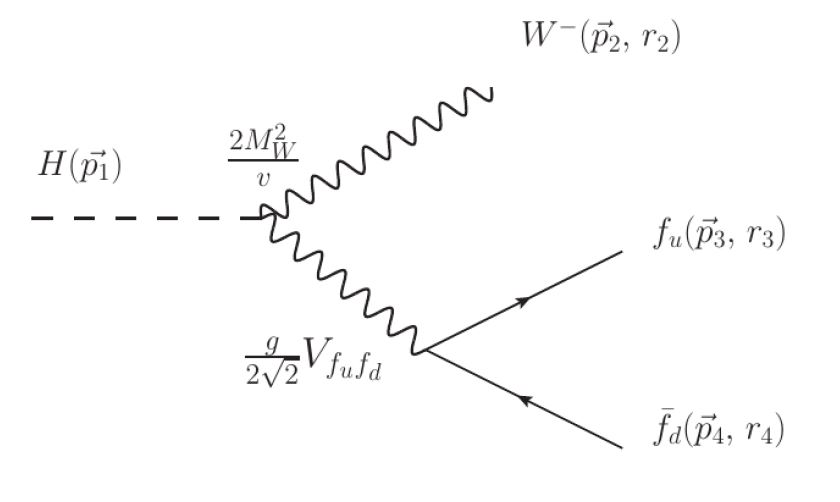

$$ \Gamma(H \to WW^*) = \frac{3 G_F^2 m_W^4}{16\pi^3} m_H R_T\left(\frac{m_W^2}{m_H^2}\right)\ , $$

$$ \Gamma(H \to ZZ^*) = \frac{3 G_F^2 m_Z^4}{16\pi^3} m_H \left(\frac{7}{12} - \frac{10}{9} \sin^2(\theta_W) + \frac{40}{9}\sin^4(\theta_W)\right)\, R_T\left(\frac{m_Z^2}{m_H^2}\right)\ , $$

donde la función que nos da la desintegración es

$$ R_T(x) = \frac{3 (20x^2 -8x +1)}{\sqrt{4x-1}} \, \arccos\left(\frac{3x-1}{2x^{3/2}}\right) - \frac{1-x}{2x}(47 x^2 -13x +2) - \frac{3}{2}(4x^2 -6x +1) \log(x)\ . $$

Nótese que estas funciones tienen una contribución infinita en el punto de unión $m_H = 2 m_{W,Z}$, lo que se corregiría incluyendo términos de mayor orden que no trataremos.

In [11]:
# En primer lugar, cálculo para desintegración en partículas reales.
# Rango de validez para estas expresiones:

print( 'Para el bosón W: m_H > %.2f GeV \nPara el bosón Z: m_H > %.2f GeV' 
      %(2 * m_W.subs(valores_masas), 2 * m_Z.subs(valores_masas)) )

Para el bosón W: m_H > 160.80 GeV 
Para el bosón Z: m_H > 182.40 GeV


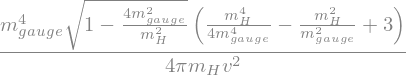

In [12]:
# Definimos la anchura parcial para esta desintegración:
# Completar.

Gamma_gauge1 = symbols('Gamma_gauge1', cls=Function)

Gamma_gauge1 = m_gauge**4/(4*pi*m_H*v**2)*sqrt(1-4*m_gauge**2/m_H**2)*(3+m_H**4/(4*m_gauge**4)-m_H**2/m_gauge**2)
Gamma_gauge1

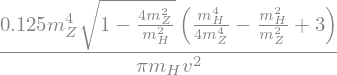

In [13]:
# Calculamos para cada bosón a tener en cuenta: W, Z
# Completar sustituyendo m_gauge por la masa de cada bosón.
# Nota: recodad incluir el factor 1 / 2 para el Z

Gamma_WW1, Gamma_ZZ1 = symbols('Gamma_WW1, Gamma_ZZ1', cls=Function)

Gamma_WW1 = Gamma_gauge1.subs(m_gauge, m_W)
Gamma_ZZ1 = 1/2*Gamma_gauge1.subs(m_gauge, m_Z)

Gamma_ZZ1

In [14]:
# Primer intento de plots: [m] = GeV
# Ojo: estas funciones tienen un rango limitado
# Completar.

rango_masas_W1 = rango_masas[rango_masas > 160.80]
rango_masas_Z1 = rango_masas[rango_masas > 182.40]

Gamma_WW1_m = lambdify( m_H, Gamma_WW1.subs(valores_masas).subs(valores), "numpy" )
Gamma_ZZ1_m = lambdify( m_H, Gamma_ZZ1.subs(valores_masas).subs(valores), "numpy" )

Gamma_WW1_m = Gamma_WW1_m(rango_masas_W1) # definimos el array numérico correspondiente, evaluando el objeto lambdify
Gamma_ZZ1_m = Gamma_ZZ1_m(rango_masas_Z1)

Text(0.5, 1.0, 'Decay rates del Higgs a un par de bosones gauge vectoriales (reales) ($m_H>2m_{gauge}$)')

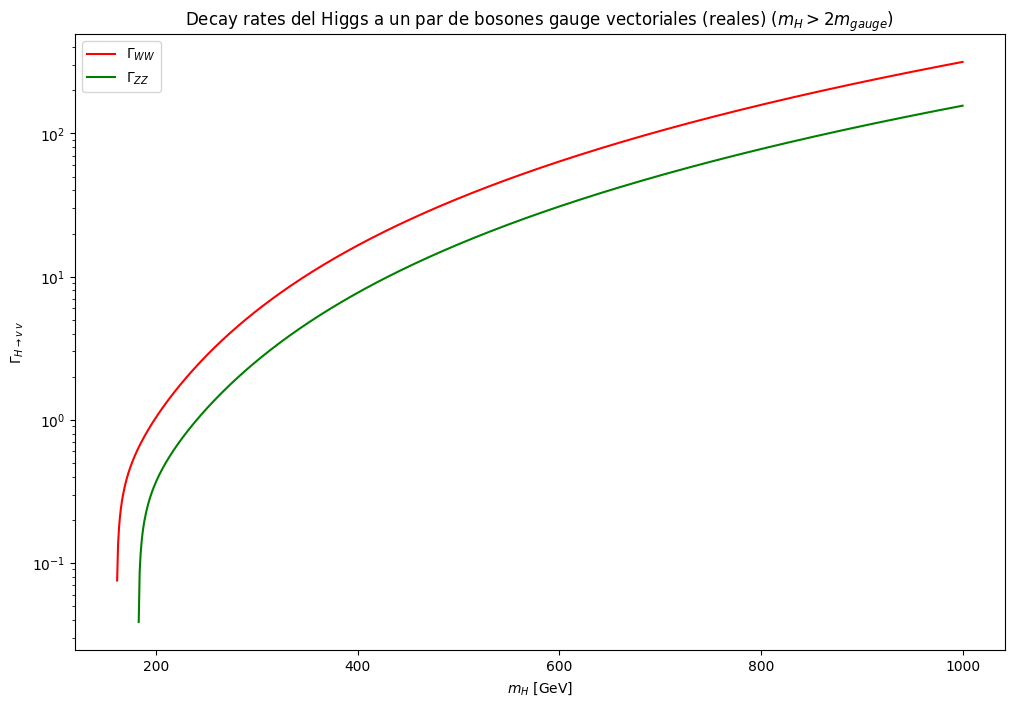

In [26]:
# Creamos un plot:
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...)
# Ojo: las expresiones a representar sólo valen en rango_masas_W1(Z1), no en el rango total

fig, ax = plt.subplots(1, figsize=(12,8))
ax.set_yscale("log")

ax.plot(rango_masas_W1, Gamma_WW1_m, 'r', label=r'$\Gamma_{WW}$') 
ax.plot(rango_masas_Z1, Gamma_ZZ1_m, 'g', label=r'$\Gamma_{ZZ}$')

ax.legend()
ax.set_xlabel(r"$m_H$" + " [GeV]")
ax.set_ylabel(r"$\Gamma_{H\to v \ v}$")
ax.set_title(r"Decay rates del Higgs a un par de bosones gauge vectoriales (reales) ($m_H>2m_{gauge}$)")

In [16]:
# En segundo lugar, cálculo para desintegración en partículas virtuales.
# Rango de validez para estas expresiones:

print( 'Para el bosón W: m_H < %.2f GeV \nPara el bosón Z: m_H < %.2f GeV' 
      %(2 * m_W.subs(valores_masas), 2 * m_Z.subs(valores_masas)) )

Para el bosón W: m_H < 160.80 GeV 
Para el bosón Z: m_H < 182.40 GeV


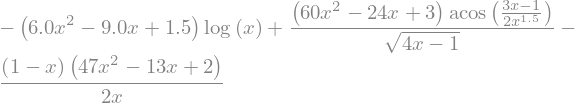

In [17]:
# Completar la expresión de R_T en función de x.

R_T = symbols('R_T', cls=Function)
x = symbols('x', real=True)

R_T = 3*(20*x**2 - 8*x + 1)/sqrt(4*x-1)*acos((3*x-1)/(2*x**(3/2))) - (1-x)/(2*x) * (47*x**2 - 13*x + 2) - 3/2*(4*x**2 - 6*x + 1)*log(x)

R_T

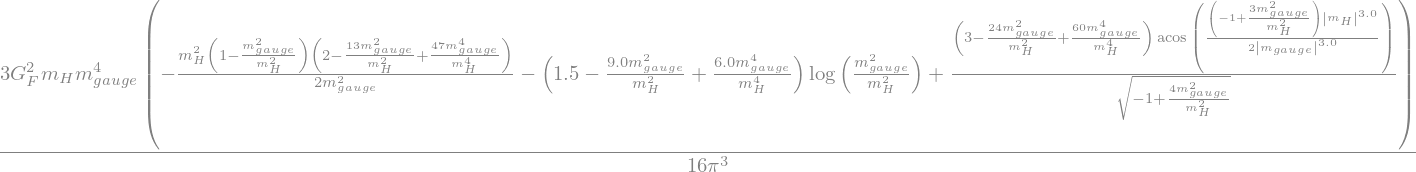

In [19]:
# Definimos la anchura parcial para esta desintegración:
# Completar la expresión de Gamma, en función de m_gauge (recordad sustituir x en R_T)
# No incluimos el factor con el ángulo de Weinberg que afecta al Z

Gamma_gauge2 = symbols('Gamma_gauge2', cls=Function)

Gamma_gauge2 = 3*G_F**2*m_gauge**4 / (16*pi**3) * m_H*R_T.subs(x, m_gauge**2/m_H**2)

Gamma_gauge2

In [20]:
# Calculamos para cada bosón a tener en cuenta: W, Z
# Completar.
# Nota: ojo al factor con el ángulo de Weinberg para el Z

Gamma_WW2, Gamma_ZZ2 = symbols('Gamma_WW2, Gamma_ZZ2', cls=Function)

Gamma_WW2 = Gamma_gauge2.subs(m_gauge, m_W)
Gamma_ZZ2 = Gamma_gauge2.subs(m_gauge, m_Z)*(7/12 - 10/9*sin(theta_W)**2 + 40/9*sin(theta_W)**4)

In [21]:
# Primer intento de plots: [m] = GeV
# Ojo: estas funciones tienen un rango limitado
# Completar.

rango_masas_W2 = rango_masas[(rango_masas <= 160.80) & (rango_masas > 80.4)]
rango_masas_Z2 = rango_masas[(rango_masas <= 182.40) & (rango_masas > 91.2)]

Gamma_WW2_m = lambdify( m_H, Gamma_WW2.subs(valores_masas).subs(valores), "numpy" )
Gamma_ZZ2_m = lambdify( m_H, Gamma_ZZ2.subs(valores_masas).subs(valores), "numpy" )

Gamma_WW2_m = Gamma_WW2_m(rango_masas_W2) # evaluación del array numérico
Gamma_ZZ2_m = Gamma_ZZ2_m(rango_masas_Z2)

Text(0.5, 1.0, 'Decay rates del Higgs a un par de bosones gauge vectoriales (virtuales) ($m_H<2m_{gauge}$)')

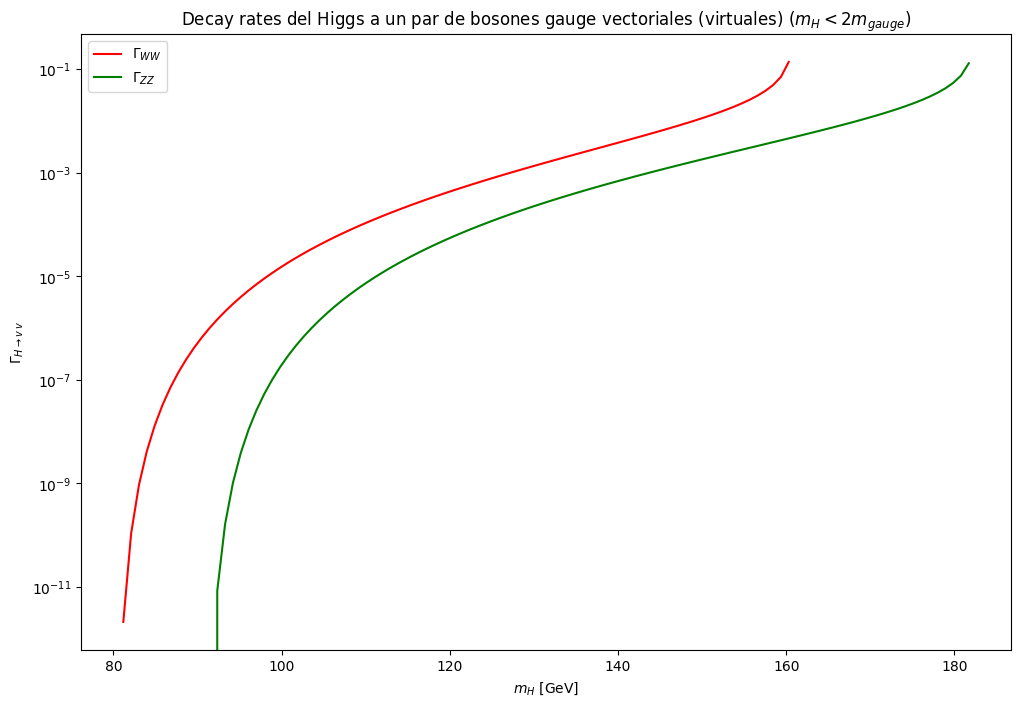

In [27]:
# Creamos un plot:
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...)
# Ojo: las expresiones a representar sólo valen en rango_masas_W2(Z2), no en el rango total


fig, ax = plt.subplots(1, figsize=(12,8))
ax.set_yscale("log")

ax.plot(rango_masas_W2, Gamma_WW2_m, 'r', label=r'$\Gamma_{WW}$') 
ax.plot(rango_masas_Z2, Gamma_ZZ2_m, 'g', label=r'$\Gamma_{ZZ}$')

ax.legend()
ax.set_xlabel(r"$m_H$" + " [GeV]")
ax.set_ylabel(r"$\Gamma_{H\to v \ v}$")
ax.set_title(r"Decay rates del Higgs a un par de bosones gauge vectoriales (virtuales) ($m_H<2m_{gauge}$)")

In [24]:
# Juntamos ambos tramos
# Nota: concatenamos arrays numéricos

rango_masas_W3 = rango_masas[rango_masas <= 80.4]
rango_masas_Z3 = rango_masas[rango_masas <= 91.2]

Gamma_WW_tot = np.concatenate([np.zeros_like(rango_masas_W3), Gamma_WW2_m, Gamma_WW1_m])
Gamma_ZZ_tot = np.concatenate([np.zeros_like(rango_masas_Z3), Gamma_ZZ2_m, Gamma_ZZ1_m])

Text(0.5, 1.0, 'Decay rates del Higgs a un par de bosones gauge vectoriales')

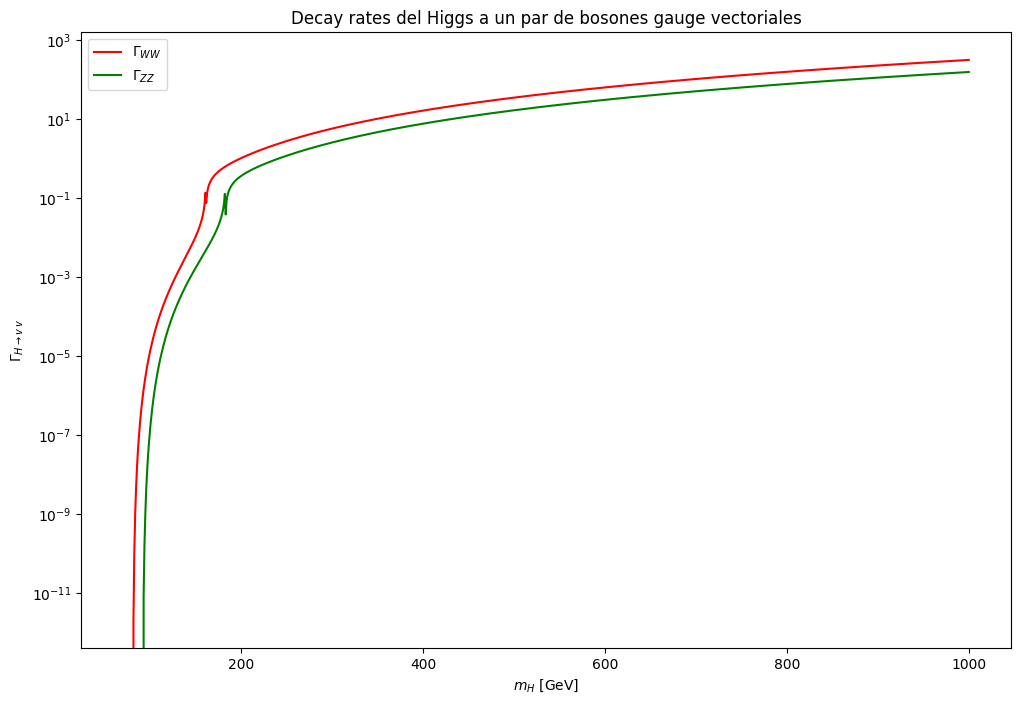

In [28]:
# Creamos un plot:
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...)
# En este caso sí representamos en rango_masas

fig, ax = plt.subplots(1, figsize=(12,8))
ax.set_yscale("log")

ax.plot(rango_masas, Gamma_WW_tot, 'r', label=r'$\Gamma_{WW}$') 
ax.plot(rango_masas, Gamma_ZZ_tot, 'g', label=r'$\Gamma_{ZZ}$')

ax.legend()
ax.set_xlabel(r"$m_H$" + " [GeV]")
ax.set_ylabel(r"$\Gamma_{H\to v \ v}$")
ax.set_title("Decay rates del Higgs a un par de bosones gauge vectoriales")

# Desintegraciones del Higgs en partículas no masivas

<font size="3">

Estas partículas no masivas no se acoplan directamente al bosón de Higgs. Sin embargo, las interacciones entre el Higgs, gluones, fotones y Z pueden ser generadas, a nivel cuántico, mediante _loops_ que incluyan partículas masivas que sí se acoplen con el Higgs. Las interacciones con fotones y Z son mediadas por _loops_ de W y fermiones cargados, mientras que las interacciones con gluones son mediadas por _loops_ de quarks. Sólo contribuyen los fermiones más masivos (_top_, y en menor medida _bottom_).

## Desintegración en un par de gluones

<font size="3">

En esta sección estudiaremos la desintegración del Higgs en un par de gluones: $H \to gg$. 

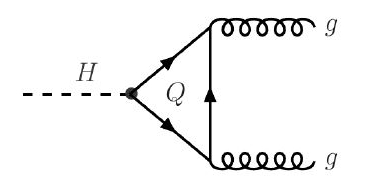

En este proceso, el _loop_ de quarks _top_ contribuye de forma importante. Nótese que el proceso inverso, en el que dos gluones colisionan dando lugar a un bosón de Higgs mediante el _loop_ de _tops_ es una de las formas más relevantes para producir el bosón de Higgs en el LHC. La anchura de este proceso viene dada por

$$ \Gamma (H\to gg) = \frac{m_t^4}{m_H 8 \pi v^2} \left(\frac{\alpha_S}{\pi}\right)^2 \bigg|D\left(\frac{m_t^2}{m_H^2}\right)\bigg|^2\ , $$

donde $\alpha_S = 0.1181$ es la constante de acoplo fuerte y la función dada es

$$ D(x) = -2 + (4x-1)\left[Li_2\left(\frac{2}{\sqrt{1-4x}+1}\right) + Li_2\left(\frac{-2}{\sqrt{1-4x}-1}\right)\right] \ . $$

Nota: la función polilogaritmo viene dada por

$$ Li_s(z) = \sum_{k=1}^\infty \frac{z^k}{k^s} \ \Rightarrow\ Li_2(\pm z) = - \int_0^z \frac{log|1\mp \zeta|}{\zeta} d\zeta\ . $$

Como puede verse esta expresión es más complicada. Para trabajar con la función polilogaritmo debemos cargar la librería _mpmath_, que incluye algunas funciones especiales en _Python_; hay que tener cuidado al cargar este módulo ya que también incluye las funciones habituales y puede sobreescribir algunos nombres de _SymPy_ y darnos problemas, por lo que lo cargaremos con un alias. Este módulo también da algunos problemas al combinarlo con _NumPy_, habrá que emplear el comando _np.float64()_ para que entienda de forma correcta los valores, así como _np.complex_ para que trabaje con complejos. Por último, no parece haber un comando directo para evaluar una función de _mpmath_ en un array (como por ejemplo hacíamos con _lambdify_); lo que parece resultar más sencillo es definir el array como una evaluación dentro de un bucle. Una vez que tengamos todo en forma de array lo representaremos con _Matplotlib_. Nótese que es importante obtener el resultado de cada parte en forma de array para combinarlos en el análisis final.

In [29]:
import mpmath as mpm 
mpm.mp.dps = 15; mpm.mp.pretty = True

#dir(mpm) # ojo: algunas funciones predeterminadas de sympy también están en mpmath

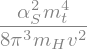

In [30]:
# Definimos la anchura parcial para esta desintegración:
# Completar la expresión, sin incluir la función D(x).

Gamma_gg = symbols('Gamma_gg', cls=Function)

Gamma_gg = m_t**4/(8*pi*m_H*v**2) * (alpha_S/pi)**2

Gamma_gg

In [31]:
# Definimos variables vacías para calcular la función D(x)

poly = zeros(1, len(rango_masas))
poly2 = zeros(1, len(rango_masas))
#poly

In [32]:
mT = np.float64(m_t.subs(valores_masas)) # Nota: hace falta convertir el tipo de dato
temp1 = 2 / ( np.sqrt(np.array(complex(1) - 4 * ( mT / rango_masas ) ** 2) ) + 1 )
temp2 = -2 / ( np.sqrt(np.array(complex(1) - 4 * ( mT / rango_masas ) ** 2) ) - 1 )
temp3 = 4 * ( mT / rango_masas ) ** 2 - 1

#temp1, temp2, temp3

In [33]:
# Ojo: tarda
for i in range(len(rango_masas)):
    poly[i] = -2 + temp3[i] * ( sympify(mpm.polylog(2, temp1[i])) + sympify(mpm.polylog(2, temp2[i])) )
    poly2[i] = Abs(poly[i]) ** 2
#poly, poly2

In [34]:
# Completar lambdify...

Gamma_gg_m = lambdify( m_H, Gamma_gg.subs(valores_masas).subs(valores), "numpy" )

Gamma_gg_tot = (Gamma_gg_m(rango_masas) * np.array(poly2))[0] # incluyendo todos los términos de la expresión

Text(0.5, 1.0, 'Decay rate del Higgs a 2 gluones')

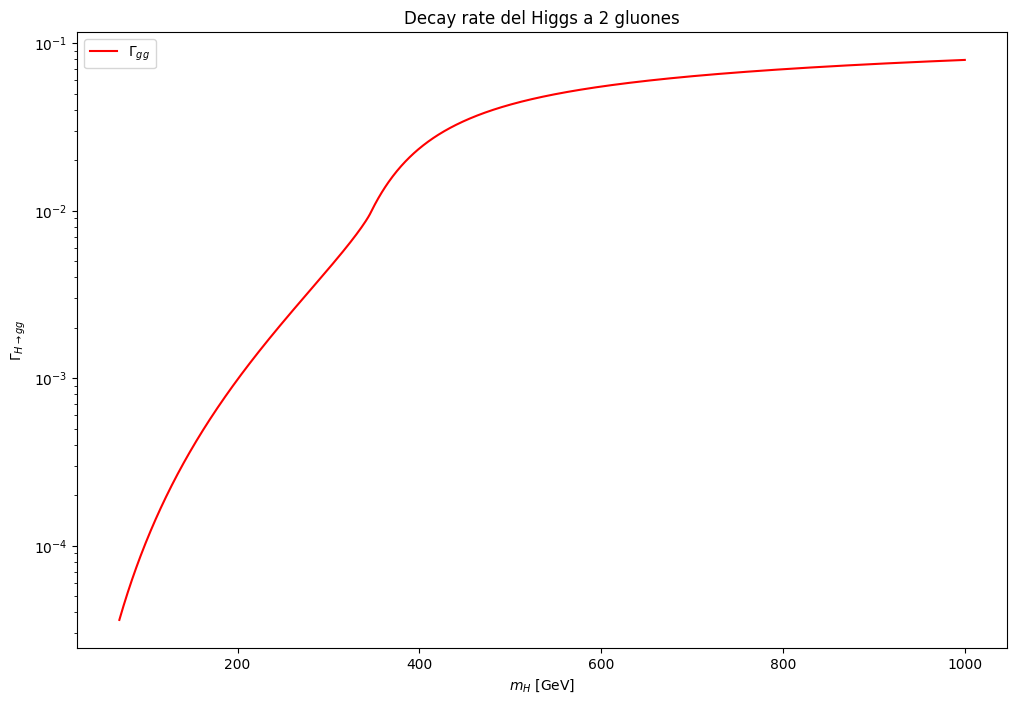

In [35]:
# Creamos un plot:
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...)
# Representamos en rango_masas

fig, ax = plt.subplots(1, figsize=(12,8))
ax.set_yscale("log")

ax.plot(rango_masas, Gamma_gg_tot, 'r', label=r'$\Gamma_{gg}$') 

ax.legend()
ax.set_xlabel(r"$m_H$" + " [GeV]")
ax.set_ylabel(r"$\Gamma_{H\to gg}$")
ax.set_title("Decay rate del Higgs a 2 gluones")

## Desintegración en un par de fotones

<font size="3">

En esta sección estudiaremos la desintegración del Higgs en un par de fotones: $H \to \gamma\gamma$.


Esta desintegración es mucho menos habitual, pero va a ser relevante para las búsquedas experimentales del bosón de Higgs y la estimación de su masa. En los _loops_ para que se produzcan fotones pueden intervenir tanto el _W_ como distintos fermiones. Habrá que tener en cuenta los factores de forma para todas estas partículas y sumar todas las posibles contribuciones por lo que la expresión será un poco más complicada:

$$ \Gamma (H\to \gamma\gamma) = \frac{G_F \alpha^2 m_H^3}{128\sqrt{2} \pi^3} \bigg|\sum_f N_C Q_f^2 A_{1/2}(\tau_f) + A_1(\tau_W) \bigg|^2\ , $$

donde $\tau_i = m_H^2/4m_i^2$, $N_C$ es el número de colores y $Q_f$ la carga; y los factores de forma para las partículas de espín $1$ y $1/2$ son

$$ A_{1/2}(\tau) = \frac{2}{\tau^2} [\tau + (\tau-1) f(\tau)]\ , $$

$$ A_1(\tau) = -\frac{1}{\tau^2} [2\tau^2 + 3\tau + 3(2\tau-1) f(\tau)] \ , $$

y la función $f$ viene definida por 

$$ f(\tau) = \begin{cases} \arcsin^2(\sqrt{\tau}) & \tau\leq 1 \\ - \frac{1}{4}\left[\log\left(\frac{1+\sqrt{1-\tau^{-1}}}{1-\sqrt{1-\tau^{-1}}}\right) - i\pi\right]^2 & \tau> 1 \end{cases} \ . $$

Nota: para definir funciones a trozos podemos usar _np.piecewise_, pero deberemos trabajarlo todo con arrays numéricos.

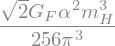

In [36]:
# Definimos la anchura parcial para esta desintegración:
# Completar el factor (sin incluir la parte del sumatorio)

FactorGamma_pp = symbols('FactorGamma_pp', cls=Function)

FactorGamma_pp = G_F*alpha**2*m_H**3/(128*sqrt(2)*pi**3)

FactorGamma_pp

In [37]:
tau_u = (rango_masas ** 2) / (4 * np.float64(m_u.subs(valores_masas)) ** 2)
tau_c = (rango_masas ** 2) / (4 * np.float64(m_c.subs(valores_masas)) ** 2)
tau_t = (rango_masas ** 2) / (4 * np.float64(m_t.subs(valores_masas)) ** 2)
tau_d = (rango_masas ** 2) / (4 * np.float64(m_d.subs(valores_masas)) ** 2)
tau_s = (rango_masas ** 2) / (4 * np.float64(m_s.subs(valores_masas)) ** 2)
tau_b = (rango_masas ** 2) / (4 * np.float64(m_b.subs(valores_masas)) ** 2)
tau_e = (rango_masas ** 2) / (4 * np.float64(m_e.subs(valores_masas)) ** 2)
tau_mu = (rango_masas ** 2) / (4 * np.float64(m_mu.subs(valores_masas)) ** 2)
tau_tau = (rango_masas ** 2) / (4 * np.float64(m_tau.subs(valores_masas)) ** 2)
tau_W = (rango_masas ** 2) / (4 * np.float64(m_W.subs(valores_masas)) ** 2)

In [38]:
f_u = np.piecewise(tau_u+0j, [tau_u <= 1, tau_u > 1], 
                   [lambda tau_u: np.arcsin(np.sqrt(tau_u)) ** 2, 
                    lambda tau_u: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_u)) / (1 - np.sqrt(1 - 1 / tau_u))) - pi * 1j) ** 2])
f_c = np.piecewise(tau_c+0j, [tau_c <= 1, tau_c > 1], 
                   [lambda tau_c: np.arcsin(np.sqrt(tau_c)) ** 2, 
                    lambda tau_c: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_c)) / (1 - np.sqrt(1 - 1 / tau_c))) - pi * 1j) ** 2])
f_t = np.piecewise(tau_t+0j, [tau_t <= 1, tau_t > 1], 
                   [lambda tau_t: np.arcsin(np.sqrt(tau_t)) ** 2, 
                    lambda tau_t: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_t)) / (1 - np.sqrt(1 - 1 / tau_t))) - pi * 1j) ** 2])
f_d = np.piecewise(tau_d+0j, [tau_d <= 1, tau_d > 1], 
                   [lambda tau_d: np.arcsin(np.sqrt(tau_d)) ** 2, 
                    lambda tau_d: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_d)) / (1 - np.sqrt(1 - 1 / tau_d))) - pi * 1j) ** 2])
f_s = np.piecewise(tau_s+0j, [tau_s <= 1, tau_s > 1], 
                   [lambda tau_s: np.arcsin(np.sqrt(tau_s)) ** 2, 
                    lambda tau_s: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_s)) / (1 - np.sqrt(1 - 1 / tau_s))) - pi * 1j) ** 2])
f_b = np.piecewise(tau_b+0j, [tau_b <= 1, tau_b > 1], 
                   [lambda tau_b: np.arcsin(np.sqrt(tau_b)) ** 2, 
                    lambda tau_b: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_b)) / (1 - np.sqrt(1 - 1 / tau_b))) - pi * 1j) ** 2])
f_e = np.piecewise(tau_e+0j, [tau_e <= 1, tau_e > 1], 
                   [lambda tau_e: np.arcsin(np.sqrt(tau_e)) ** 2, 
                    lambda tau_e: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_e)) / (1 - np.sqrt(1 - 1 / tau_e))) - pi * 1j) ** 2])
f_mu = np.piecewise(tau_mu+0j, [tau_mu <= 1, tau_mu > 1], 
                   [lambda tau_mu: np.arcsin(np.sqrt(tau_mu)) ** 2, 
                    lambda tau_mu: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_mu)) / (1 - np.sqrt(1 - 1 / tau_mu))) - pi * 1j) ** 2])
f_tau = np.piecewise(tau_tau+0j, [tau_tau <= 1, tau_tau > 1], 
                   [lambda tau_tau: np.arcsin(np.sqrt(tau_tau)) ** 2, 
                    lambda tau_tau: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_tau)) / (1 - np.sqrt(1 - 1 / tau_tau))) - pi * 1j) ** 2])
f_W = np.piecewise(tau_W+0j, [tau_W <= 1, tau_W > 1], 
                   [lambda tau_W: np.arcsin(np.sqrt(tau_W)) ** 2, 
                    lambda tau_W: (-1 / 4) * (np.log((1 + np.sqrt(1 - 1 / tau_W)) / (1 - np.sqrt(1 - 1 / tau_W))) - pi * 1j) ** 2])

In [39]:
A12_u = (2 / tau_u ** 2) * (tau_u + (tau_u - 1) * f_u)
A12_c = (2 / tau_c ** 2) * (tau_c + (tau_c - 1) * f_c)
A12_t = (2 / tau_t ** 2) * (tau_t + (tau_t - 1) * f_t)
A12_d = (2 / tau_d ** 2) * (tau_d + (tau_d - 1) * f_d)
A12_s = (2 / tau_s ** 2) * (tau_s + (tau_s - 1) * f_s)
A12_b = (2 / tau_b ** 2) * (tau_b + (tau_b - 1) * f_b)
A12_e = (2 / tau_e ** 2) * (tau_e + (tau_e - 1) * f_e)
A12_mu = (2 / tau_mu ** 2) * (tau_mu + (tau_mu - 1) * f_mu)
A12_tau = (2 / tau_tau ** 2) * (tau_tau + (tau_tau - 1) * f_tau)
A1_W = (-1 / tau_W ** 2) * (2 * tau_W ** 2 + 3 * tau_W + 3 * (2 * tau_W - 1) * f_W)

In [40]:
AbsLoopGamma_pp_sum = np.abs(      3*(4 / 9) * (A12_u + A12_c + A12_t) +
                     3*(1 / 9) * (A12_d + A12_s + A12_b) +
                     1*(A12_e + A12_mu + A12_tau)    +    1 * A1_W    )
#AbsLoopGamma_pp_sum

In [41]:
# Completar lambdify... FactorGamma_pp

FactorGamma_pp_m = lambdify( m_H, FactorGamma_pp.subs(valores_masas).subs(valores), "numpy" )

Gamma_pp_tot = (FactorGamma_pp_m(rango_masas) * (AbsLoopGamma_pp_sum ** 2)) # incluyendo todos los términos de la expresión

Text(0.5, 1.0, 'Decay rate del Higgs a 2 fotones')

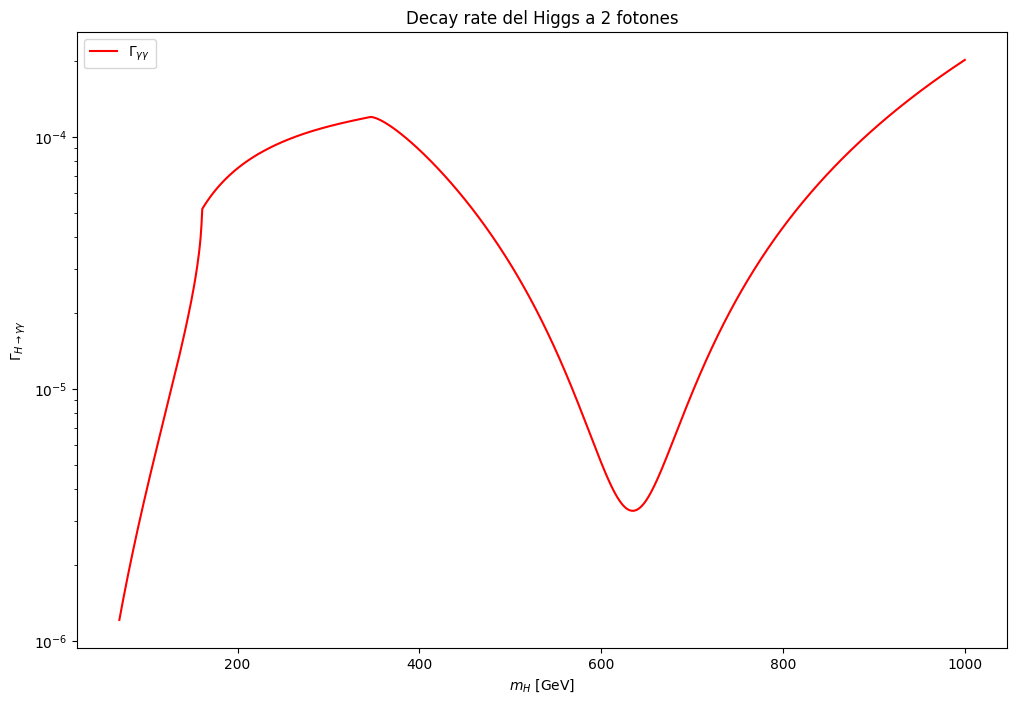

In [42]:
# Creamos un plot: FactorGamma_pp_m * (AbsLoopGamma_pp_sum^2)
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...)

fig, ax = plt.subplots(1, figsize=(12,8))
ax.set_yscale("log")

ax.plot(rango_masas, Gamma_pp_tot, 'r', label=r'$\Gamma_{\gamma\gamma}$') 

ax.legend()
ax.set_xlabel(r"$m_H$" + " [GeV]")
ax.set_ylabel(r"$\Gamma_{H\to \gamma\gamma}$")
ax.set_title("Decay rate del Higgs a 2 fotones")

## Desintegración en fotón - bosón Z

En esta sección estudiaremos la desintegración del Higgs en un bosón Z y un fotón: $H \to Z\gamma$.

Este proceso viene dado por diagramas análogos a los de la desintegración en dos fotones, incluyendo igualmente una suma a todos los fermiones y el _W_, con sus respectivos factores de forma. Las expresiones con el _Z_ son sin embargo más complicadas ya que incluyen factores con $\theta_W$ así como otros términos. 

$$ \Gamma (H\to Z\gamma) = \frac{G_F^2 m_W^2\alpha m_H^3}{64\pi^4} \left(1 - \frac{m_Z^2}{m_H^2}\right)^3 \bigg|\sum_f \frac{N_f Q_f \tilde{v}_f}{c_W} \tilde{A}_{1/2} (\tilde{\tau}_f,\tilde{\lambda}_f) + \tilde{A}_1(\tilde{\tau}_W,\tilde{\lambda}_W))\bigg|^2 \ , $$

donde $\tilde{\tau}_i = 4m_i^2/m_H^2= \tau_i^{-1} , \tilde{\lambda}_i = 4m_i^2/m_Z^2, \tilde{v}_f = 2I^3_f - 4Q_f s_W^2, s_W\equiv \sin(\theta_W), c_W\equiv \cos(\theta_W)$, y los factores de forma para este proceso son

$$ \tilde{A}_{1/2} (\tilde{\tau},\tilde{\lambda}) = I_1(\tilde{\tau},\tilde{\lambda}) - I_2(\tilde{\tau},\tilde{\lambda}) \ , $$


$$ \tilde{A}_1(\tilde{\tau},\tilde{\lambda}) = c_W \left\{\left[\left(1+\frac{2}{\tilde{\tau}}\right)\frac{s_W^2}{c_W^2}-5-\frac{2}{\tilde{\tau}}\right] I_1(\tilde{\tau},\tilde{\lambda}) + 4\left(3-\frac{s_W^2}{c_W^2}\right)I_2(\tilde{\tau},\tilde{\lambda}) \right\} \ , $$

y las funciones $I_1$ e $I_2$ vienen dadas por

$$ I_1(\tilde{\tau},\tilde{\lambda}) = \frac{\tilde{\tau}\tilde{\lambda}}{2(\tilde{\tau}-\tilde{\lambda})} + \frac{\tilde{\tau}^2\tilde{\lambda}^2}{2(\tilde{\tau}-\tilde{\lambda})^2}[f(\tilde{\tau}^{-1}) - f(\tilde{\lambda}^{-1})] + \frac{\tilde{\tau}^2\tilde{\lambda}}{(\tilde{\tau}-\tilde{\lambda})^2} [g(\tilde{\tau}^{-1}) - g(\tilde{\lambda}^{-1})] \ , $$

$$ I_2(\tilde{\tau},\tilde{\lambda}) = -\frac{\tilde{\tau}\tilde{\lambda}}{2(\tilde{\tau}-\tilde{\lambda})} [f(\tilde{\tau}^{-1}) - f(\tilde{\lambda}^{-1})] \ , $$

donde

$$ f(\tau) = \begin{cases} \arcsin^2(\sqrt{\tau}) &  \tau \leq 1 \\ - \frac{1}{4}\left[\log\left(\frac{1+\sqrt{1- \tau^{-1}}}{1-\sqrt{1-\tau^{-1}}}\right) - i\pi\right]^2 & \tau> 1 \end{cases} \ , $$


$$ g(\tau) = \begin{cases}  \sqrt{\tau^{-1}-1} \arcsin^2(\sqrt{\tau}) & \tau\leq 1  \\  \frac{\sqrt{1-\tau^{-1}}}{2}\left[\log\left(\frac{1+\sqrt{1-\tau^{-1}}}{1-\sqrt{1-\tau^{-1}}}\right) - i\pi\right]^2 & \tau> 1  \end{cases} \ . $$

De igual forma que en el caso anterior, definimos todas las funciones implicadas y calculamos el sumatorio final.

(Nótese la errata en la expresión de $g(\tau)$ en Ec. (2.56) de Djouadi, https://arxiv.org/abs/hep-ph/0503172)

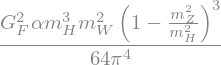

In [43]:
# Definimos la anchura parcial para esta desintegración:
# Completar el factor (sin el sumatorio)
# El resto se hará de nuevo de forma numérica.

FactorGamma_Zp = symbols('FactorGamma_Zp', cls=Function)

FactorGamma_Zp = G_F**2*m_W**2*alpha*m_H**3/(64*pi**4) * (1-m_Z**2/m_H**2)**3

FactorGamma_Zp

In [44]:
tauZ_u = (4 * np.float64(m_u.subs(valores_masas)) ** 2) / (rango_masas ** 2)
tauZ_c = (4 * np.float64(m_c.subs(valores_masas)) ** 2) / (rango_masas ** 2)
tauZ_t = (4 * np.float64(m_t.subs(valores_masas)) ** 2) / (rango_masas ** 2)
tauZ_d = (4 * np.float64(m_d.subs(valores_masas)) ** 2) / (rango_masas ** 2)
tauZ_s = (4 * np.float64(m_s.subs(valores_masas)) ** 2) / (rango_masas ** 2)
tauZ_b = (4 * np.float64(m_b.subs(valores_masas)) ** 2) / (rango_masas ** 2)
tauZ_e = (4 * np.float64(m_e.subs(valores_masas)) ** 2) / (rango_masas ** 2)
tauZ_mu = (4 * np.float64(m_mu.subs(valores_masas)) ** 2) / (rango_masas ** 2)
tauZ_tau = (4 * np.float64(m_tau.subs(valores_masas)) ** 2) / (rango_masas ** 2)
tauZ_W = (4 * np.float64(m_W.subs(valores_masas)) ** 2) / (rango_masas ** 2)

lambdaZ_u = (4 * np.float64(m_u.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)
lambdaZ_c = (4 * np.float64(m_c.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)
lambdaZ_t = (4 * np.float64(m_t.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)
lambdaZ_d = (4 * np.float64(m_d.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)
lambdaZ_s = (4 * np.float64(m_s.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)
lambdaZ_b = (4 * np.float64(m_b.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)
lambdaZ_e = (4 * np.float64(m_e.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)
lambdaZ_mu = (4 * np.float64(m_mu.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)
lambdaZ_tau = (4 * np.float64(m_tau.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)
lambdaZ_W = (4 * np.float64(m_W.subs(valores_masas)) ** 2) / (np.float64(m_Z.subs(valores_masas)) ** 2)

In [45]:
ftauZ_u = np.piecewise(tauZ_u+0j, [tauZ_u > 1, tauZ_u <= 1], 
                   [lambda tauZ_u: np.arcsin(np.sqrt(1 / tauZ_u)) ** 2, 
                    lambda tauZ_u: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_u)) / (1 - np.sqrt(1 - tauZ_u))) - pi * 1j) ** 2])
ftauZ_c = np.piecewise(tauZ_c+0j, [tauZ_c > 1, tauZ_c <= 1], 
                   [lambda tauZ_c: np.arcsin(np.sqrt(1 / tauZ_c)) ** 2, 
                    lambda tauZ_c: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_c)) / (1 - np.sqrt(1 - tauZ_c))) - pi * 1j) ** 2])
ftauZ_t = np.piecewise(tauZ_t+0j, [tauZ_t > 1, tauZ_t <= 1], 
                   [lambda tauZ_t: np.arcsin(np.sqrt(1 / tauZ_t)) ** 2, 
                    lambda tauZ_t: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_t)) / (1 - np.sqrt(1 - tauZ_t))) - pi * 1j) ** 2])
ftauZ_d = np.piecewise(tauZ_d+0j, [tauZ_d > 1, tauZ_d <= 1], 
                   [lambda tauZ_d: np.arcsin(np.sqrt(1 / tauZ_d)) ** 2, 
                    lambda tauZ_d: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_d)) / (1 - np.sqrt(1 - tauZ_d))) - pi * 1j) ** 2])
ftauZ_s = np.piecewise(tauZ_s+0j, [tauZ_s > 1, tauZ_s <= 1], 
                   [lambda tauZ_s: np.arcsin(np.sqrt(1 / tauZ_s)) ** 2, 
                    lambda tauZ_s: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_s)) / (1 - np.sqrt(1 - tauZ_s))) - pi * 1j) ** 2])
ftauZ_b = np.piecewise(tauZ_b+0j, [tauZ_b > 1, tauZ_b <= 1], 
                   [lambda tauZ_b: np.arcsin(np.sqrt(1 / tauZ_b)) ** 2, 
                    lambda tauZ_b: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_b)) / (1 - np.sqrt(1 - tauZ_b))) - pi * 1j) ** 2])
ftauZ_e = np.piecewise(tauZ_e+0j, [tauZ_e > 1, tauZ_e <= 1], 
                   [lambda tauZ_e: np.arcsin(np.sqrt(1 / tauZ_e)) ** 2, 
                    lambda tauZ_e: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_e)) / (1 - np.sqrt(1 - tauZ_e))) - pi * 1j) ** 2])
ftauZ_mu = np.piecewise(tauZ_mu+0j, [tauZ_mu > 1, tauZ_mu <= 1], 
                   [lambda tauZ_mu: np.arcsin(np.sqrt(1 / tauZ_mu)) ** 2, 
                    lambda tauZ_mu: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_mu)) / (1 - np.sqrt(1 - tauZ_mu))) - pi * 1j) ** 2])
ftauZ_tau = np.piecewise(tauZ_tau+0j, [tauZ_tau > 1, tauZ_tau <= 1], 
                   [lambda tauZ_tau: np.arcsin(np.sqrt(1 / tauZ_tau)) ** 2, 
                    lambda tauZ_tau: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_tau)) / (1 - np.sqrt(1 - tauZ_tau))) - pi * 1j) ** 2])
ftauZ_W = np.piecewise(tauZ_W+0j, [tauZ_W > 1, tauZ_W <= 1], 
                   [lambda tauZ_W: np.arcsin(np.sqrt(1 / tauZ_W)) ** 2, 
                    lambda tauZ_W: (-1 / 4) * (np.log((1 + np.sqrt(1 - tauZ_W)) / (1 - np.sqrt(1 - tauZ_W))) - pi * 1j) ** 2])

flambdaZ_u = np.piecewise(lambdaZ_u+0j, [lambdaZ_u > 1, lambdaZ_u <= 1], 
                   [lambda lambdaZ_u: np.arcsin(np.sqrt(1 / lambdaZ_u)) ** 2, 
                    lambda lambdaZ_u: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_u)) / (1 - np.sqrt(1 - lambdaZ_u))) - pi * 1j) ** 2])
flambdaZ_c = np.piecewise(lambdaZ_c+0j, [lambdaZ_c > 1, lambdaZ_c <= 1], 
                   [lambda lambdaZ_c: np.arcsin(np.sqrt(1 / lambdaZ_c)) ** 2, 
                    lambda lambdaZ_c: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_c)) / (1 - np.sqrt(1 - lambdaZ_c))) - pi * 1j) ** 2])
flambdaZ_t = np.piecewise(lambdaZ_t+0j, [lambdaZ_t > 1, lambdaZ_t <= 1], 
                   [lambda lambdaZ_t: np.arcsin(np.sqrt(1 / lambdaZ_t)) ** 2, 
                    lambda lambdaZ_t: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_t)) / (1 - np.sqrt(1 - lambdaZ_t))) - pi * 1j) ** 2])
flambdaZ_d = np.piecewise(lambdaZ_d+0j, [lambdaZ_d > 1, lambdaZ_d <= 1], 
                   [lambda lambdaZ_d: np.arcsin(np.sqrt(1 / lambdaZ_d)) ** 2, 
                    lambda lambdaZ_d: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_d)) / (1 - np.sqrt(1 - lambdaZ_d))) - pi * 1j) ** 2])
flambdaZ_s = np.piecewise(lambdaZ_s+0j, [lambdaZ_s > 1, lambdaZ_s <= 1], 
                   [lambda lambdaZ_s: np.arcsin(np.sqrt(1 / lambdaZ_s)) ** 2, 
                    lambda lambdaZ_s: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_s)) / (1 - np.sqrt(1 - lambdaZ_s))) - pi * 1j) ** 2])
flambdaZ_b = np.piecewise(lambdaZ_b+0j, [lambdaZ_b > 1, lambdaZ_b <= 1], 
                   [lambda lambdaZ_b: np.arcsin(np.sqrt(1 / lambdaZ_b)) ** 2, 
                    lambda lambdaZ_b: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_b)) / (1 - np.sqrt(1 - lambdaZ_b))) - pi * 1j) ** 2])
flambdaZ_e = np.piecewise(lambdaZ_e+0j, [lambdaZ_e > 1, lambdaZ_e <= 1], 
                   [lambda lambdaZ_e: np.arcsin(np.sqrt(1 / lambdaZ_e)) ** 2, 
                    lambda lambdaZ_e: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_e)) / (1 - np.sqrt(1 - lambdaZ_e))) - pi * 1j) ** 2])
flambdaZ_mu = np.piecewise(lambdaZ_mu+0j, [lambdaZ_mu > 1, lambdaZ_mu <= 1], 
                   [lambda lambdaZ_mu: np.arcsin(np.sqrt(1 / lambdaZ_mu)) ** 2, 
                    lambda lambdaZ_mu: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_mu)) / (1 - np.sqrt(1 - lambdaZ_mu))) - pi * 1j) ** 2])
flambdaZ_tau = np.piecewise(lambdaZ_tau+0j, [lambdaZ_tau > 1, lambdaZ_tau <= 1], 
                   [lambda lambdaZ_tau: np.arcsin(np.sqrt(1 / lambdaZ_tau)) ** 2, 
                    lambda lambdaZ_tau: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_tau)) / (1 - np.sqrt(1 - lambdaZ_tau))) - pi * 1j) ** 2])
flambdaZ_W = np.piecewise(lambdaZ_W+0j, [lambdaZ_W > 1, lambdaZ_W <= 1], 
                   [lambda lambdaZ_W: np.arcsin(np.sqrt(1 / lambdaZ_W)) ** 2, 
                    lambda lambdaZ_W: (-1 / 4) * (np.log((1 + np.sqrt(1 - lambdaZ_W)) / (1 - np.sqrt(1 - lambdaZ_W))) - pi * 1j) ** 2])


gtauZ_u = np.piecewise(tauZ_u+0j, [ tauZ_u < 1 , tauZ_u >= 1], 
                   [lambda tauZ_u: (1 / 2) * np.sqrt(1-tauZ_u) * (np.log((1 + np.sqrt(1 - tauZ_u)) / (1 - np.sqrt(1 - tauZ_u))) - pi * 1j) ** 2, 
                    lambda tauZ_u: np.sqrt(tauZ_u - 1) * np.arcsin(np.sqrt(1 / tauZ_u)) ** 2 ])
gtauZ_c = np.piecewise(tauZ_c+0j, [ tauZ_c < 1 , tauZ_c >= 1 ], 
                   [lambda tauZ_c: (1 / 2) * np.sqrt(1-tauZ_c) * (np.log((1 + np.sqrt(1 - tauZ_c)) / (1 - np.sqrt(1 - tauZ_c))) - pi * 1j) ** 2, 
                    lambda tauZ_c: np.sqrt(tauZ_c - 1) * np.arcsin(np.sqrt(1 / tauZ_c)) ** 2 ])
gtauZ_t = np.piecewise(tauZ_t+0j, [ tauZ_t < 1 , tauZ_t >= 1], 
                   [lambda tauZ_t: (1 / 2) * np.sqrt(1-tauZ_t) * (np.log((1 + np.sqrt(1 - tauZ_t)) / (1 - np.sqrt(1 - tauZ_t))) - pi * 1j) ** 2, 
                    lambda tauZ_t: np.sqrt(tauZ_t - 1) * np.arcsin(np.sqrt(1 / tauZ_t)) ** 2 ])
gtauZ_d = np.piecewise(tauZ_d+0j, [ tauZ_d < 1 , tauZ_d >= 1 ], 
                   [lambda tauZ_d: (1 / 2) * np.sqrt(1-tauZ_d) * (np.log((1 + np.sqrt(1 - tauZ_d)) / (1 - np.sqrt(1 - tauZ_d))) - pi * 1j) ** 2, 
                    lambda tauZ_d: np.sqrt(tauZ_d - 1) * np.arcsin(np.sqrt(1 / tauZ_d)) ** 2 ])
gtauZ_s = np.piecewise(tauZ_s+0j, [ tauZ_s < 1 , tauZ_s >= 1 ], 
                   [lambda tauZ_s: (1 / 2) * np.sqrt(1-tauZ_s) * (np.log((1 + np.sqrt(1 - tauZ_s)) / (1 - np.sqrt(1 - tauZ_s))) - pi * 1j) ** 2, 
                    lambda tauZ_s: np.sqrt(tauZ_s - 1) * np.arcsin(np.sqrt(1 / tauZ_s)) ** 2 ])
gtauZ_b = np.piecewise(tauZ_b+0j, [ tauZ_b < 1 , tauZ_b >= 1 ], 
                   [lambda tauZ_b: (1 / 2) * np.sqrt(1-tauZ_b) * (np.log((1 + np.sqrt(1 - tauZ_b)) / (1 - np.sqrt(1 - tauZ_b))) - pi * 1j) ** 2, 
                    lambda tauZ_b: np.sqrt(tauZ_b - 1) * np.arcsin(np.sqrt(1 / tauZ_b)) ** 2 ])
gtauZ_e = np.piecewise(tauZ_e+0j, [ tauZ_e < 1 , tauZ_e >= 1 ], 
                   [lambda tauZ_e: (1 / 2) * np.sqrt(1-tauZ_e) * (np.log((1 + np.sqrt(1 - tauZ_e)) / (1 - np.sqrt(1 - tauZ_e))) - pi * 1j) ** 2, 
                    lambda tauZ_e: np.sqrt(tauZ_e - 1) * np.arcsin(np.sqrt(1 / tauZ_e)) ** 2 ])
gtauZ_mu = np.piecewise(tauZ_mu+0j, [ tauZ_mu < 1 , tauZ_mu >= 1 ], 
                   [lambda tauZ_mu: (1 / 2) * np.sqrt(1-tauZ_mu) * (np.log((1 + np.sqrt(1 - tauZ_mu)) / (1 - np.sqrt(1 - tauZ_mu))) - pi * 1j) ** 2, 
                    lambda tauZ_mu: np.sqrt(tauZ_mu - 1) * np.arcsin(np.sqrt(1 / tauZ_mu)) ** 2 ])
gtauZ_tau = np.piecewise(tauZ_tau+0j, [ tauZ_tau < 1 , tauZ_tau >= 1], 
                   [lambda tauZ_tau: (1 / 2) * np.sqrt(1-tauZ_tau) * (np.log((1 + np.sqrt(1 - tauZ_tau)) / (1 - np.sqrt(1 - tauZ_tau))) - pi * 1j) ** 2, 
                    lambda tauZ_tau: np.sqrt(tauZ_tau - 1) * np.arcsin(np.sqrt(1 / tauZ_tau)) ** 2 ])
gtauZ_W = np.piecewise(tauZ_W+0j, [ tauZ_W < 1 , tauZ_W >= 1 ], 
                   [lambda tauZ_W: (1 / 2) * np.sqrt(1-tauZ_W) * (np.log((1 + np.sqrt(1 - tauZ_W)) / (1 - np.sqrt(1 - tauZ_W))) - pi * 1j) ** 2, 
                    lambda tauZ_W: np.sqrt(tauZ_W - 1) * np.arcsin(np.sqrt(1 / tauZ_W)) ** 2 ])


glambdaZ_u = np.piecewise(lambdaZ_u+0j, [ lambdaZ_u < 1 , lambdaZ_u >= 1 ], 
                   [lambda lambdaZ_u: (1 / 2) * np.sqrt(1-lambdaZ_u) * (np.log((1 + np.sqrt(1 - lambdaZ_u)) / (1 - np.sqrt(1 - lambdaZ_u))) - pi * 1j) ** 2, 
                    lambda lambdaZ_u: np.sqrt(lambdaZ_u - 1) * np.arcsin(np.sqrt(1 / lambdaZ_u)) ** 2 ])
glambdaZ_c = np.piecewise(lambdaZ_c+0j, [ lambdaZ_c < 1 , lambdaZ_c >= 1 ], 
                   [lambda lambdaZ_c: (1 / 2) * np.sqrt(1-lambdaZ_c) * (np.log((1 + np.sqrt(1 - lambdaZ_c)) / (1 - np.sqrt(1 - lambdaZ_c))) - pi * 1j) ** 2, 
                    lambda lambdaZ_c: np.sqrt(lambdaZ_c - 1) * np.arcsin(np.sqrt(1 / lambdaZ_c)) ** 2 ])
glambdaZ_t = np.piecewise(lambdaZ_t+0j, [ lambdaZ_t < 1 , lambdaZ_t >= 1 ], 
                   [lambda lambdaZ_t: (1 / 2) * np.sqrt(1-lambdaZ_t) * (np.log((1 + np.sqrt(1 - lambdaZ_t)) / (1 - np.sqrt(1 - lambdaZ_t))) - pi * 1j) ** 2, 
                    lambda lambdaZ_t: np.sqrt(lambdaZ_t - 1) * np.arcsin(np.sqrt(1 / lambdaZ_t)) ** 2 ])
glambdaZ_d = np.piecewise(lambdaZ_d+0j, [ lambdaZ_d < 1 , lambdaZ_d >= 1 ], 
                   [lambda lambdaZ_d: (1 / 2) * np.sqrt(1-lambdaZ_d) * (np.log((1 + np.sqrt(1 - lambdaZ_d)) / (1 - np.sqrt(1 - lambdaZ_d))) - pi * 1j) ** 2, 
                    lambda lambdaZ_d: np.sqrt(lambdaZ_d - 1) * np.arcsin(np.sqrt(1 / lambdaZ_d)) ** 2 ])
glambdaZ_s = np.piecewise(lambdaZ_s+0j, [ lambdaZ_s < 1 , lambdaZ_s >= 1 ], 
                   [lambda lambdaZ_s: (1 / 2) * np.sqrt(1-lambdaZ_s) * (np.log((1 + np.sqrt(1 - lambdaZ_s)) / (1 - np.sqrt(1 - lambdaZ_s))) - pi * 1j) ** 2, 
                    lambda lambdaZ_s: np.sqrt(lambdaZ_s - 1) * np.arcsin(np.sqrt(1 / lambdaZ_s)) ** 2 ])
glambdaZ_b = np.piecewise(lambdaZ_b+0j, [ lambdaZ_b < 1 , lambdaZ_b >= 1 ], 
                   [lambda lambdaZ_b: (1 / 2) * np.sqrt(1-lambdaZ_b) * (np.log((1 + np.sqrt(1 - lambdaZ_b)) / (1 - np.sqrt(1 - lambdaZ_b))) - pi * 1j) ** 2, 
                    lambda lambdaZ_b: np.sqrt(lambdaZ_b - 1) * np.arcsin(np.sqrt(1 / lambdaZ_b)) ** 2 ])
glambdaZ_e = np.piecewise(lambdaZ_e+0j, [ lambdaZ_e < 1 , lambdaZ_e >= 1 ], 
                   [lambda lambdaZ_e: (1 / 2) * np.sqrt(1-lambdaZ_e) * (np.log((1 + np.sqrt(1 - lambdaZ_e)) / (1 - np.sqrt(1 - lambdaZ_e))) - pi * 1j) ** 2, 
                    lambda lambdaZ_e: np.sqrt(lambdaZ_e - 1) * np.arcsin(np.sqrt(1 / lambdaZ_e)) ** 2 ])
glambdaZ_mu = np.piecewise(lambdaZ_mu+0j, [ lambdaZ_mu < 1 , lambdaZ_mu >= 1 ], 
                   [lambda lambdaZ_mu: (1 / 2) * np.sqrt(1-lambdaZ_mu) * (np.log((1 + np.sqrt(1 - lambdaZ_mu)) / (1 - np.sqrt(1 - lambdaZ_mu))) - pi * 1j) ** 2, 
                    lambda lambdaZ_mu: np.sqrt(lambdaZ_mu - 1) * np.arcsin(np.sqrt(1 / lambdaZ_mu)) ** 2 ])
glambdaZ_tau = np.piecewise(lambdaZ_tau+0j, [ lambdaZ_tau < 1 , lambdaZ_tau >= 1 ], 
                   [lambda lambdaZ_tau: (1 / 2) * np.sqrt(1-lambdaZ_tau) * (np.log((1 + np.sqrt(1 - lambdaZ_tau)) / (1 - np.sqrt(1 - lambdaZ_tau))) - pi * 1j) ** 2, 
                    lambda lambdaZ_tau: np.sqrt(lambdaZ_tau - 1) * np.arcsin(np.sqrt(1 / lambdaZ_tau)) ** 2 ])
glambdaZ_W = np.piecewise(lambdaZ_W+0j, [ lambdaZ_W < 1 , lambdaZ_W >= 1 ], 
                   [lambda lambdaZ_W: (1 / 2) * np.sqrt(1-lambdaZ_W) * (np.log((1 + np.sqrt(1 - lambdaZ_W)) / (1 - np.sqrt(1 - lambdaZ_W))) - pi * 1j) ** 2, 
                    lambda lambdaZ_W: np.sqrt(lambdaZ_W - 1) * np.arcsin(np.sqrt(1 / lambdaZ_W)) ** 2 ])

In [46]:
I1_u = (tauZ_u * lambdaZ_u) / (2 * (tauZ_u - lambdaZ_u)) + (
    (tauZ_u * lambdaZ_u) / (  (tauZ_u - lambdaZ_u) )) ** 2  * (ftauZ_u - flambdaZ_u)/2 + (
    (tauZ_u ** 2 * lambdaZ_u) / (tauZ_u - lambdaZ_u) ** 2 * (gtauZ_u - glambdaZ_u))
I1_c = (tauZ_c * lambdaZ_c) / (2 * (tauZ_c - lambdaZ_c)) + (
    (tauZ_c * lambdaZ_c) / ( (tauZ_c - lambdaZ_c))) ** 2  * (ftauZ_c - flambdaZ_c)/2 + (
    (tauZ_c ** 2 * lambdaZ_c) / (tauZ_c - lambdaZ_c) ** 2 * (gtauZ_c - glambdaZ_c))
I1_t = (tauZ_t * lambdaZ_t) / (2 * (tauZ_t - lambdaZ_t)) + (
    (tauZ_t * lambdaZ_t) / ( (tauZ_t - lambdaZ_t))) ** 2  * (ftauZ_t - flambdaZ_t)/2 + (
    (tauZ_t ** 2 * lambdaZ_t) / (tauZ_t - lambdaZ_t) ** 2 * (gtauZ_t - glambdaZ_t))
I1_d = (tauZ_d * lambdaZ_d) / (2 * (tauZ_d - lambdaZ_d)) + (
    (tauZ_d * lambdaZ_d) / ( (tauZ_d - lambdaZ_d))) ** 2  * (ftauZ_d - flambdaZ_d)/2 + (
    (tauZ_d ** 2 * lambdaZ_d) / (tauZ_d - lambdaZ_d) ** 2 * (gtauZ_d - glambdaZ_d))
I1_s = (tauZ_s * lambdaZ_s) / (2 * (tauZ_s - lambdaZ_s)) + (
    (tauZ_s * lambdaZ_s) / ( (tauZ_s - lambdaZ_s))) ** 2  * (ftauZ_s - flambdaZ_s)/2 + (
    (tauZ_s ** 2 * lambdaZ_s) / (tauZ_s - lambdaZ_s) ** 2 * (gtauZ_s - glambdaZ_s))
I1_b = (tauZ_b * lambdaZ_b) / (2 * (tauZ_b - lambdaZ_b)) + (
    (tauZ_b * lambdaZ_b) / ( (tauZ_b - lambdaZ_b))) ** 2  * (ftauZ_b - flambdaZ_b)/2 + (
    (tauZ_b ** 2 * lambdaZ_b) / (tauZ_b - lambdaZ_b) ** 2 * (gtauZ_b - glambdaZ_b))
I1_e = (tauZ_e * lambdaZ_e) / (2 * (tauZ_e - lambdaZ_e)) + (
    (tauZ_e * lambdaZ_e) / ( (tauZ_e - lambdaZ_e))) ** 2 * (ftauZ_e - flambdaZ_e)/2 + (
    (tauZ_e ** 2 * lambdaZ_e) / (tauZ_e - lambdaZ_e) ** 2 * (gtauZ_e - glambdaZ_e))
I1_mu = (tauZ_mu * lambdaZ_mu) / (2 * (tauZ_mu - lambdaZ_mu)) + (
    (tauZ_mu * lambdaZ_mu) / ( (tauZ_mu - lambdaZ_mu))) ** 2 * (ftauZ_mu - flambdaZ_mu)/2 + (
    (tauZ_mu ** 2 * lambdaZ_mu) / (tauZ_mu - lambdaZ_mu) ** 2 * (gtauZ_mu - glambdaZ_mu))
I1_tau = (tauZ_tau * lambdaZ_tau) / (2 * (tauZ_tau - lambdaZ_tau)) + (
    (tauZ_tau * lambdaZ_tau) / ( (tauZ_tau - lambdaZ_tau))) ** 2 * (ftauZ_tau - flambdaZ_tau)/2 + (
    (tauZ_tau ** 2 * lambdaZ_tau) / (tauZ_tau - lambdaZ_tau) ** 2 * (gtauZ_tau - glambdaZ_tau))
I1_W = (tauZ_W * lambdaZ_W) / (2 * (tauZ_W - lambdaZ_W)) + (
    (tauZ_W * lambdaZ_W) / ( (tauZ_W - lambdaZ_W))) ** 2 * (ftauZ_W - flambdaZ_W)/2 + (
    (tauZ_W ** 2 * lambdaZ_W) / (tauZ_W - lambdaZ_W) ** 2 * (gtauZ_W - glambdaZ_W))

I2_u = -(tauZ_u * lambdaZ_u) / (2 * (tauZ_u - lambdaZ_u)) * (ftauZ_u - flambdaZ_u) 
I2_c = -(tauZ_c * lambdaZ_c) / (2 * (tauZ_c - lambdaZ_c)) * (ftauZ_c - flambdaZ_c) 
I2_t = -(tauZ_t * lambdaZ_t) / (2 * (tauZ_t - lambdaZ_t)) * (ftauZ_t - flambdaZ_t) 
I2_d = -(tauZ_d * lambdaZ_d) / (2 * (tauZ_d - lambdaZ_d)) * (ftauZ_d - flambdaZ_d) 
I2_s = -(tauZ_s * lambdaZ_s) / (2 * (tauZ_s - lambdaZ_s)) * (ftauZ_s - flambdaZ_s) 
I2_b = -(tauZ_b * lambdaZ_b) / (2 * (tauZ_b - lambdaZ_b)) * (ftauZ_b - flambdaZ_b) 
I2_e = -(tauZ_e * lambdaZ_e) / (2 * (tauZ_e - lambdaZ_e)) * (ftauZ_e - flambdaZ_e) 
I2_mu = -(tauZ_mu * lambdaZ_mu) / (2 * (tauZ_mu - lambdaZ_mu)) * (ftauZ_mu - flambdaZ_mu) 
I2_tau = -(tauZ_tau * lambdaZ_tau) / (2 * (tauZ_tau - lambdaZ_tau)) * (ftauZ_tau - flambdaZ_tau) 
I2_W = -(tauZ_W * lambdaZ_W) / (2 * (tauZ_W - lambdaZ_W)) * (ftauZ_W - flambdaZ_W) 

In [47]:
sW = np.float64(sin(theta_W).subs(valores))
cW = np.float64(cos(theta_W).subs(valores))
#sW ** 2

In [48]:
A12Z_u = I1_u - I2_u
A12Z_c = I1_c - I2_c
A12Z_t = I1_t - I2_t
A12Z_d = I1_d - I2_d
A12Z_s = I1_s - I2_s
A12Z_b = I1_b - I2_b
A12Z_e = I1_e - I2_e
A12Z_mu = I1_mu - I2_mu
A12Z_tau = I1_tau - I2_tau
A1Z_W = cW * ( ( (1 + 2 / tauZ_W) * (sW / cW) ** 2 - 5 - 2 / tauZ_W ) * I1_W + 4 * (3 - (sW / cW) ** 2) * I2_W)

In [49]:
AbsLoopGamma_Zp_sum = np.abs( (2 * (1 - (8 / 3) * sW ** 2) / cW) * (A12Z_u + A12Z_c + A12Z_t) + 
                     (-1 * (-1 + (4 / 3) * sW ** 2) / cW) * (A12Z_d + A12Z_s + A12Z_b) - 
                     ((-1 + 4 * sW ** 2) / cW) * (A12Z_e + A12Z_mu + A12Z_tau) + A1Z_W )
#AbsLoopGamma_Zp_sum

In [50]:
# Completar lambdify ... FactorGamma_Zp

FactorGamma_Zp_m = lambdify( m_H, FactorGamma_Zp.subs(valores_masas).subs(valores), "numpy" )

Gamma_Zp_tot = (FactorGamma_Zp_m(rango_masas) * (AbsLoopGamma_Zp_sum ** 2)) # incluyendo todos los términos de la expresión

Text(0.5, 1.0, 'Decay rate de $H\\to Z\\gamma$')

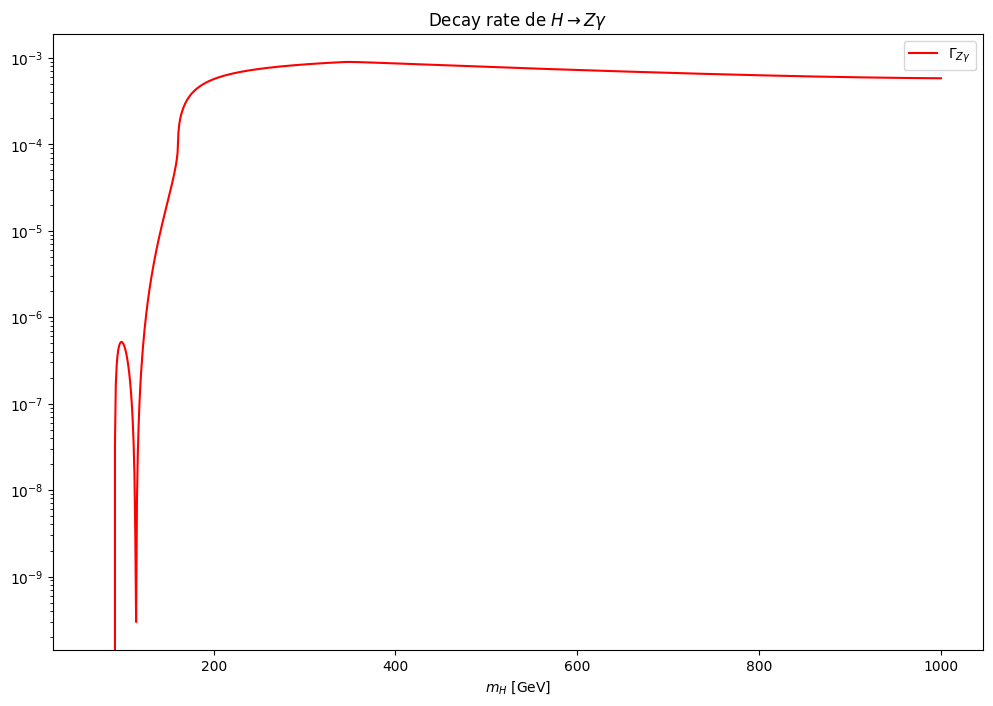

In [51]:
# Creamos un plot: FactorGamma_Zp_m * (AbsLoopGamma_Zp_sum^2)
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...)

fig, ax = plt.subplots(1, figsize=(12,8))
ax.set_yscale("log")

ax.plot(rango_masas, Gamma_Zp_tot, 'r', label=r'$\Gamma_{Z\gamma}$') 

xmin, xmax, ymin, ymax = ax.axis('tight')
ax.axis([xmin, xmax, ymin, ymax])

ax.legend()
ax.set_xlabel(r"$m_H$" + " [GeV]")
ax.set_title(r"Decay rate de $H\to Z\gamma$")

# Anchura total de desintegración y _branching ratios_


Una vez que tenemos calculadas las anchuras parciales de todos los canales más relevantes, podemos proceder a calcular la anchura total de desintegración del Higgs, $\Gamma_H$, como la suma de todos los canales. Esta anchura total dependerá, como todo lo calculado, de la masa del Higgs. 

Por otra parte, resulta muy interesante no sólo conocer la anchura total, sino saber qué canales son los que principalmente contribuyen a la misma, para cada masa. Como hemos visto, hay canales cuya anchura es mayor para masas altas, otros para masas bajas, y unos tienen más peso que otro. Saber para cada masa qué canales predominan en la desintegración del Higgs es muy útil para saber cómo buscarlo. En el siguiente apartado veremos, para la masa real del Higgs, cuál es el resultado.

En primer lugar podemos representar todas las anchuras parciales juntas, para hacernos una idea de cuáles son más relevantes. A continuación, definiremos la anchura total como la suma de todas, y la representaremos también. _Nota: hay que tener cuidado con cómo se ha definido cada anchura, para que al final las tengamos todas en forma de array para poder sumarlas y manejarlas juntas._

Finalmente, definiremos los _branching ratios_, dividiendo la anchura parcial de cada canal entre la anchura total: $\Gamma_i / \Gamma_H$. Esto nos dará su peso relativo (respecto a $1$); representaremos estas anchuras en otra gráfica.

Text(0.5, 1.0, 'Decay rates del Higgs en sus principales canales')

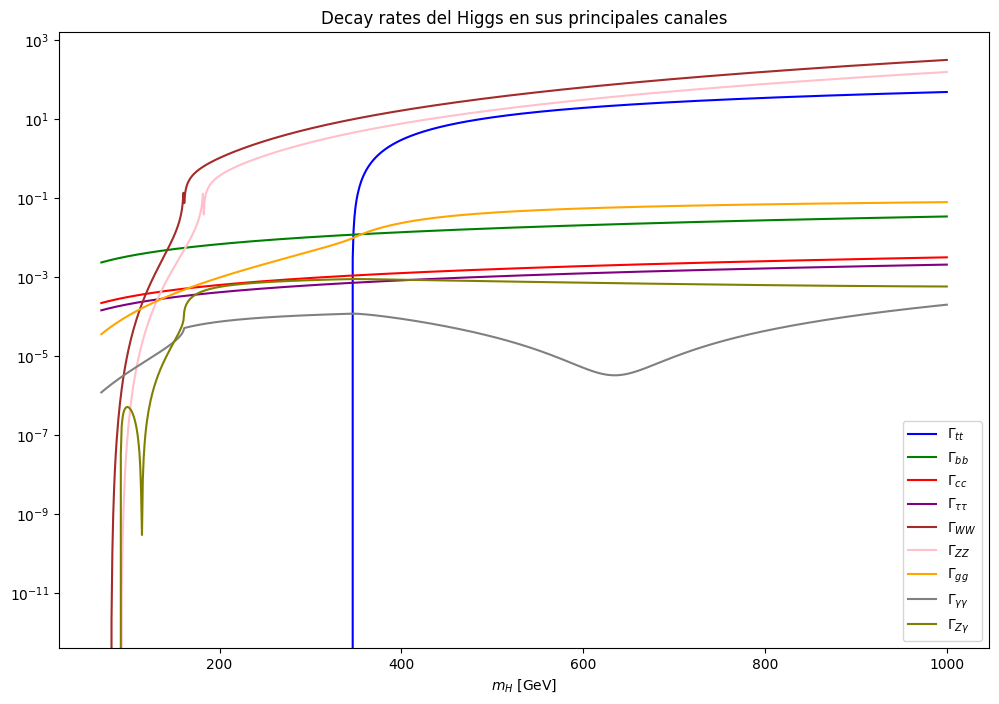

In [52]:
# Creamos un plot con todas las Gammas
# Recordad de qué forma se había definido cada una
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...)

fig, ax = plt.subplots(1, figsize=(12,8))
ax.set_yscale("log")

# Fermions

ax.plot(rango_masas, Gamma_tt_tot, 'b', label=r'$\Gamma_{tt}$')
ax.plot(rango_masas, Gamma_bb_tot, 'g', label=r'$\Gamma_{bb}$')
ax.plot(rango_masas, Gamma_cc_tot, 'r', label=r'$\Gamma_{cc}$')
ax.plot(rango_masas, Gamma_tautau_tot, 'purple', label=r'$\Gamma_{\tau\tau}$')

# Vector bosons

ax.plot(rango_masas, Gamma_WW_tot, 'brown', label=r'$\Gamma_{WW}$') 
ax.plot(rango_masas, Gamma_ZZ_tot, 'pink', label=r'$\Gamma_{ZZ}$')

# Gluons

ax.plot(rango_masas, Gamma_gg_tot, 'orange', label=r'$\Gamma_{gg}$') 

# Photons

ax.plot(rango_masas, Gamma_pp_tot, 'gray', label=r'$\Gamma_{\gamma\gamma}$') 

# Z + gamma

ax.plot(rango_masas, Gamma_Zp_tot, 'olive', label=r'$\Gamma_{Z\gamma}$')

ax.legend()
ax.set_xlabel(r"$m_H$" + " [GeV]")
ax.set_title(r"Decay rates del Higgs en sus principales canales")

In [53]:
# Definir la Gamma total como la suma de todas las calculadas
# Hay que sumar de forma numérica todos los arrays (los mismos que se han representado en el plot anterior)

Gamma_H_tot = Gamma_tt_tot + Gamma_bb_tot + Gamma_cc_tot + Gamma_tautau_tot + Gamma_WW_tot + Gamma_ZZ_tot + Gamma_gg_tot + Gamma_pp_tot + Gamma_Zp_tot


In [54]:
print( len(Gamma_tt_tot),
      len(Gamma_bb_tot),
      len(Gamma_cc_tot),
      len(Gamma_tautau_tot),
      len(Gamma_WW_tot),
      len(Gamma_ZZ_tot),
      len(Gamma_gg_tot),
      len(Gamma_pp_tot),
      len(Gamma_Zp_tot),   
      len(Gamma_H_tot) )

1000 1000 1000 1000 1000 1000 1000 1000 1000 1000


In [55]:
print( (Gamma_tt_tot)[:5],
      (Gamma_bb_tot)[:5],
      (Gamma_cc_tot)[:5],
      (Gamma_tautau_tot)[:5],
      (Gamma_WW_tot)[:5],
      (Gamma_ZZ_tot)[:5],
      (Gamma_gg_tot)[:5],
      (Gamma_pp_tot)[:5],
      (Gamma_Zp_tot)[:5],               
      (Gamma_H_tot)[:5] )

[0. 0. 0. 0. 0.] [0.00236104 0.00239379 0.00242653 0.00245925 0.00249195] [0.00022226 0.00022523 0.00022819 0.00023116 0.00023413] [0.00014526 0.0001472  0.00014915 0.0001511  0.00015304] [0. 0. 0. 0. 0.] [0. 0. 0. 0. 0.] [3.61025465469750e-5 3.75818655004528e-5 3.91018719363206e-5
 4.06631731691127e-5 4.22663795734450e-5] [1.21378850e-06 1.26576862e-06 1.31939299e-06 1.37470153e-06
 1.43173520e-06] [-1.84995829e-05 -1.65894066e-05 -1.48395126e-05 -1.32377757e-05
 -1.17730413e-05] [0.00274737300657137 0.00278848232646721 0.00282945617187745
 0.00287030797836910 0.00291105018213506]


Text(0.5, 1.0, 'Decay rate total del Higgs')

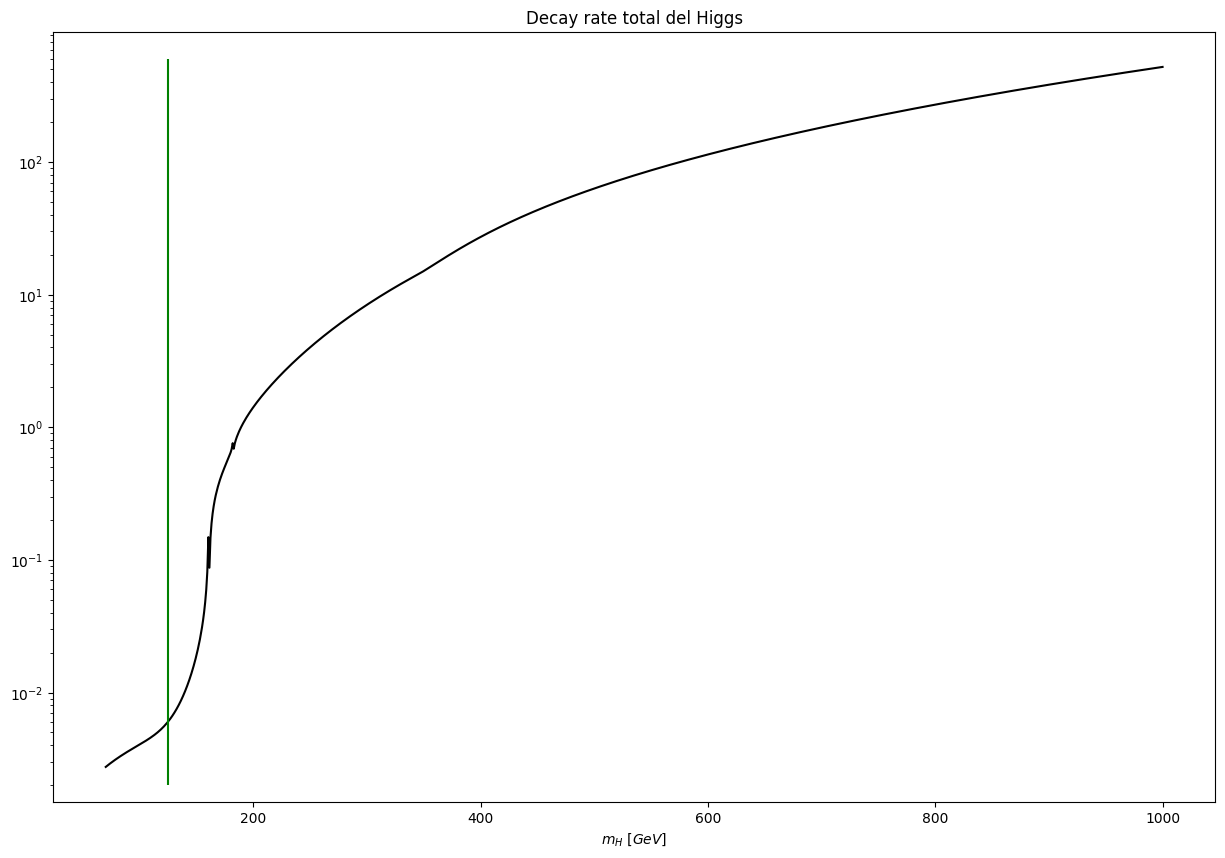

In [56]:
# Creamos un plot con la Gamma total.
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...)
# Incluimos línea que marca la masa real del Higgs.

fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.set_yscale("log")

ax.plot(rango_masas, Gamma_H_tot, 'k')

ax.vlines(125, 2 * 10 ** -3, 6 * 10 ** 2, colors='green', linestyles='solid', label=r'$125\ {\rm GeV}$')
ax.set_xlabel(r"$m_H \ [GeV]$")
ax.set_title("Decay rate total del Higgs")



#fig.savefig('anchura_total.png');    

In [57]:
# Definimos los branching ratios dividiendo cada Gamma entre la Gamma total (array / array)

BRparcial_tt = Gamma_tt_tot / Gamma_H_tot
BRparcial_bb = Gamma_bb_tot / Gamma_H_tot
BRparcial_cc = Gamma_cc_tot / Gamma_H_tot
BRparcial_tautau = Gamma_tautau_tot / Gamma_H_tot
BRparcial_WW = Gamma_WW_tot / Gamma_H_tot
BRparcial_ZZ = Gamma_ZZ_tot / Gamma_H_tot
BRparcial_gg = Gamma_gg_tot / Gamma_H_tot
BRparcial_pp = Gamma_pp_tot / Gamma_H_tot
BRparcial_Zp = Gamma_Zp_tot / Gamma_H_tot 

Text(0.5, 1.0, 'Branching Ratios del Higgs en sus principales canales')

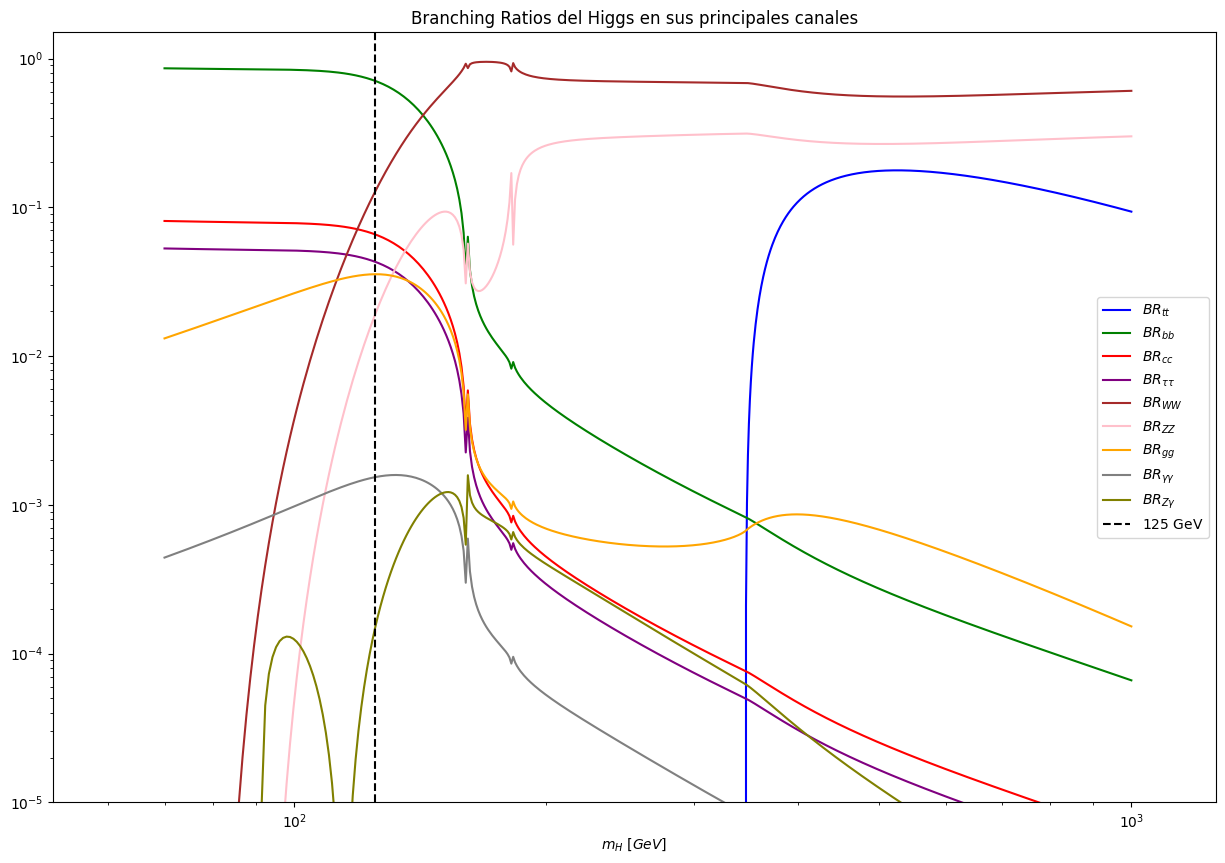

In [58]:
# Creamos un plot con los branching ratios:
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$...$'
# fig.suptitle(" ... " + r'$...$', fontsize = ...) 
# Incluir la línea en 125 GeV

fig, ax = plt.subplots(1, figsize=(15,10)) 


ax.set_xscale('log')
ax.set_yscale('log')

# Fermions

ax.plot(rango_masas, BRparcial_tt, 'b', label=r'$BR_{tt}$')
ax.plot(rango_masas, BRparcial_bb, 'g', label=r'$BR_{bb}$')
ax.plot(rango_masas, BRparcial_cc, 'r', label=r'$BR_{cc}$')
ax.plot(rango_masas, BRparcial_tautau, 'purple', label=r'$BR_{\tau\tau}$')

# Vector bosons

ax.plot(rango_masas, BRparcial_WW, 'brown', label=r'$BR_{WW}$') 
ax.plot(rango_masas, BRparcial_ZZ, 'pink', label=r'$BR_{ZZ}$')

# Gluons

ax.plot(rango_masas, BRparcial_gg, 'orange', label=r'$BR_{gg}$') 

# Photons

ax.plot(rango_masas, BRparcial_pp, 'gray', label=r'$BR_{\gamma\gamma}$') 

# Z + gamma

ax.plot(rango_masas, BRparcial_Zp, 'olive', label=r'$BR_{Z\gamma}$')

ax.vlines(125, 10 ** -5, 1.5 * 10 ** 0, colors='k', linestyle="--", label=r'$125\ {\rm GeV}$')
ax.legend()

x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([x_min+50, x_max - 100, 10 ** -5, 1.5 * 10 ** 0])
ax.set_xlabel(r"$m_H \ [GeV]$")
ax.set_title("Branching Ratios del Higgs en sus principales canales")



#fig.savefig('branching_ratios.png'); 

## Comportamiento de la anchura total en 125 GeV

Hemos analizado cómo depende el comportamiento de todos los canales de desintegración de la masa del Higgs, tomándola como parámetro libre. Sin embargo, como ya sabemos esta masa ya ha sido medida, obteniéndose un valor de $m_H=125$ GeV. Por tanto, nos interesa ahora ver los resultados del análisis que hemos hecho para esta masa, y ver qué canales son en los que realmente se está desintegrando el Higgs observado. Para ello evaluaremos todas las funciones anteriores, calculando la $\Gamma_H$ total del Higgs y la probabilidad (en %) de que se desintegre en los distintos canales. Asimismo podemos ampliar la gráfica anterior para ver el comportamiento de estas funciones en el entorno cercano de $125$ GeV. _Nota: como tenemos todo definido en forma de arrays, lo más sencillo es localizar en el rango de masas la posición que ocupa el valor más cercano a la masa real del Higgs para localizar el valor correspondiente en el resto de arrays._

Podemos comparar estos resultados con los valores obtenidos por los distintos experimentos, por ejemplo véase el [PDG](http://pdg.lbl.gov/2019/reviews/rpp2019-rev-higgs-boson.pdf). No obstante debemos recordar que en esta práctica hemos trabajado sólo con las aproximaciones de orden más bajo, además de no tener en cuenta errores en datos (masas, acoplamientos, etc.). Por ello, aunque con nuestros resultados esperamos reproducir el comportamiento general de las funciones, estimación del peso de los canales y demás, no debe preocuparnos que numéricamente no obtengamos los resultados exactos. Hacer un cálculo completo de estos resultados queda fuera de estas prácticas.



<font size="3">


In [59]:
# Encontrar en nuestro rango de masas el valor más cercano a la masa real del Higgs:

idx = np.abs(rango_masas-125).argmin()
m_H_closest = rango_masas[idx]
m_H_closest

In [60]:
# Calcular la anchura total para la masa real del Higgs (evaluar el array en el valor encontrado antes)

print( 'Anchura total = %.2f GeV' % Gamma_H_tot[idx]) # realmente 0.006 GeV

Anchura total = 0.01 GeV


In [61]:
# Calcular las BR parciales para la masa real del Higgs:

print( 'BR parcial H -> tt: %.2f' % (BRparcial_tt[idx] * 100), '%' )
print( 'BR parcial H -> bb: %.2f' % (BRparcial_bb[idx] * 100), '%' )
print( 'BR parcial H -> cc: %.2f' % (BRparcial_cc[idx] * 100), '%' )
print( 'BR parcial H -> tautau: %.2f' % (BRparcial_tautau[idx] * 100), '%' )
print( 'BR parcial H -> WW: %.2f' % (BRparcial_WW[idx] * 100), '%' )
print( 'BR parcial H -> ZZ: %.2f' % (BRparcial_ZZ[idx] * 100), '%' )
print( 'BR parcial H -> gg: %.2f' % (BRparcial_gg[idx] * 100), '%' )
print( 'BR parcial H -> pp: %.2f' % (BRparcial_pp[idx] * 100), '%' )
print( 'BR parcial H -> Zp: %.2f' % (BRparcial_Zp[idx] * 100), '%' )

BR parcial H -> tt: 0.00 %
BR parcial H -> bb: 70.77 %
BR parcial H -> cc: 6.57 %
BR parcial H -> tautau: 4.30 %
BR parcial H -> WW: 12.73 %
BR parcial H -> ZZ: 1.90 %
BR parcial H -> gg: 3.55 %
BR parcial H -> pp: 0.15 %
BR parcial H -> Zp: 0.01 %


**Observación:** suman 99.98%, hemos escogido bien los canales de desintegración. Con todo, este porcentaje está sujeto a cierto error por el empleo de métodos perturbativos, siendo la fuente de error dominante el hecho de que la mayoría de cálculos de decay rates se han quedado a nivel árbol. Con toda seguridad, esto explica asimismo la discrepancia entre el valor real del branching ratio del Higgs (0.006 GeV) y nuestro valor obtenido (0.01GeV), si bien como estimación de orden de magnitud es aceptable (aunque estrictamente habría que ver qué error tiene nuestra estimación). Tal vez sería más interesante invertir el planteamiento que hemos hecho: encontrar dónde nuestros Branching Ratios coinciden con sus valores experimentales (daría una curva aproximadamente recta en la vertical de la masa), ajustar a una vertical y extraer así una estimación de la masa del Higgs

Text(0.5, 1.0, "BRs of Higgs' main decay channels")

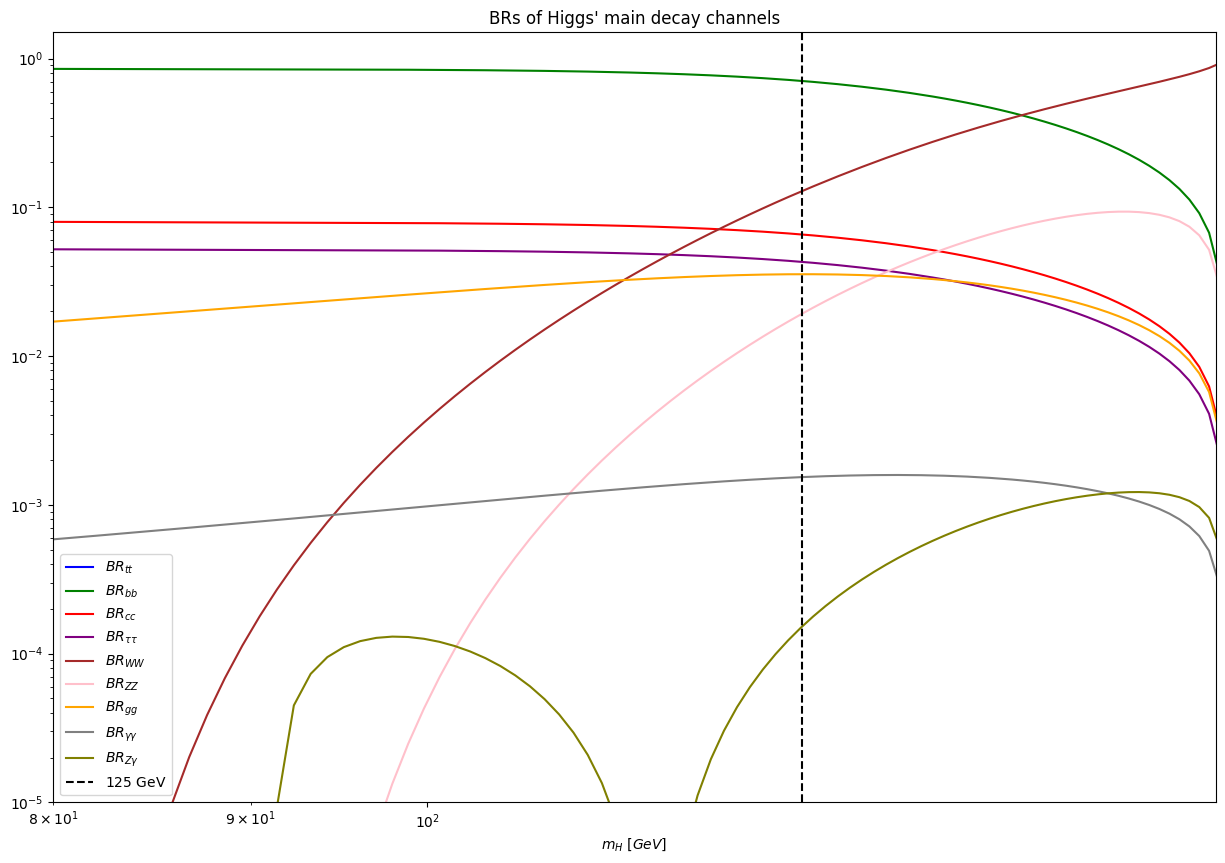

In [62]:
# Restringir el plot anterior a una región cercana a la masa del Higgs.
# Por ejemplo, probad a representar m_H en [80, 160] o en [120, 130].


fig, ax = plt.subplots(1, figsize=(15,10)) 


ax.set_xscale('log')
ax.set_yscale('log')

# Fermions

ax.plot(rango_masas, BRparcial_tt, 'b', label=r'$BR_{tt}$')
ax.plot(rango_masas, BRparcial_bb, 'g', label=r'$BR_{bb}$')
ax.plot(rango_masas, BRparcial_cc, 'r', label=r'$BR_{cc}$')
ax.plot(rango_masas, BRparcial_tautau, 'purple', label=r'$BR_{\tau\tau}$')

# Vector bosons

ax.plot(rango_masas, BRparcial_WW, 'brown', label=r'$BR_{WW}$') 
ax.plot(rango_masas, BRparcial_ZZ, 'pink', label=r'$BR_{ZZ}$')

# Gluons

ax.plot(rango_masas, BRparcial_gg, 'orange', label=r'$BR_{gg}$') 

# Photons

ax.plot(rango_masas, BRparcial_pp, 'gray', label=r'$BR_{\gamma\gamma}$') 

# Z + gamma

ax.plot(rango_masas, BRparcial_Zp, 'olive', label=r'$BR_{Z\gamma}$')

ax.vlines(125, 10 ** -5, 1.5 * 10 ** 0, colors='k', linestyle="--", label=r'$125\ {\rm GeV}$')
ax.legend()

x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([80, 160, 10 ** -5, 1.5 * 10 ** 0])
ax.set_xlabel(r"$m_H \ [GeV]$")
ax.set_title("BRs of Higgs' main decay channels")



#fig.savefig('branching_ratios.png'); 

Text(0.5, 1.0, "BRs of Higgs' main decay channels")

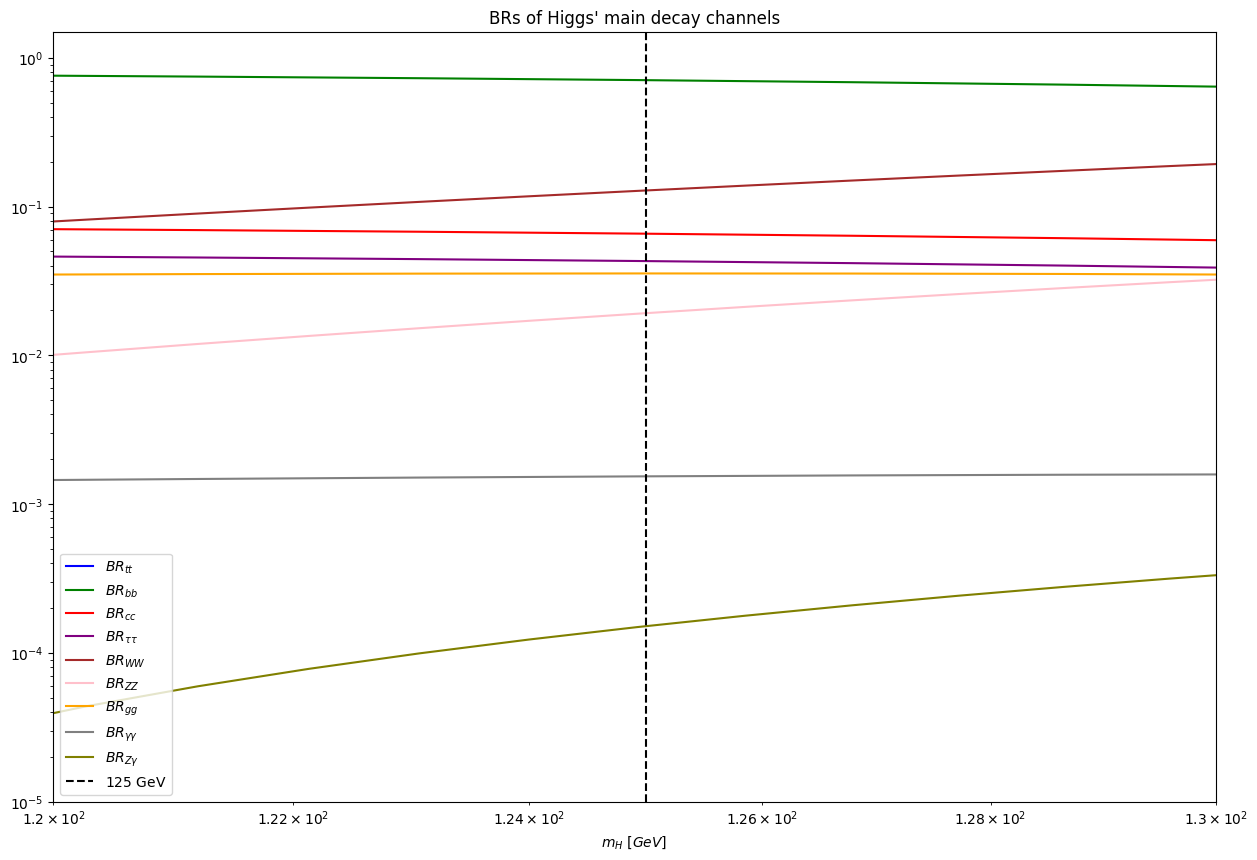

In [63]:
# Restringir el plot anterior a una región cercana a la masa del Higgs.
# Por ejemplo, probad a representar m_H en [80, 160] o en [120, 130].


fig, ax = plt.subplots(1, figsize=(15,10)) 


ax.set_xscale('log')
ax.set_yscale('log')

# Fermions

ax.plot(rango_masas, BRparcial_tt, 'b', label=r'$BR_{tt}$')
ax.plot(rango_masas, BRparcial_bb, 'g', label=r'$BR_{bb}$')
ax.plot(rango_masas, BRparcial_cc, 'r', label=r'$BR_{cc}$')
ax.plot(rango_masas, BRparcial_tautau, 'purple', label=r'$BR_{\tau\tau}$')

# Vector bosons

ax.plot(rango_masas, BRparcial_WW, 'brown', label=r'$BR_{WW}$') 
ax.plot(rango_masas, BRparcial_ZZ, 'pink', label=r'$BR_{ZZ}$')

# Gluons

ax.plot(rango_masas, BRparcial_gg, 'orange', label=r'$BR_{gg}$') 

# Photons

ax.plot(rango_masas, BRparcial_pp, 'gray', label=r'$BR_{\gamma\gamma}$') 

# Z + gamma

ax.plot(rango_masas, BRparcial_Zp, 'olive', label=r'$BR_{Z\gamma}$')

ax.vlines(125, 10 ** -5, 1.5 * 10 ** 0, colors='k', linestyle="--", label=r'$125\ {\rm GeV}$')
ax.legend()

x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([120, 130, 10 ** -5, 1.5 * 10 ** 0])
ax.set_xlabel(r"$m_H \ [GeV]$")
ax.set_title("BRs of Higgs' main decay channels")



#fig.savefig('branching_ratios.png'); 

In [65]:
print("--- %.2f seconds ---" % (time.time() - start_time))
print("--- %.2f minutes ---" % ((time.time() - start_time) / 60))

--- 1690.16 seconds ---
--- 28.17 minutes ---


# Conclusiones 

<font size="3">
<p> Se entregarán escritas a mano en la hoja facilitada durante los últimos 15 minutos de la práctica.

Además se entregará posteriormente este notebook completo en la tarea correspondiente del campus virtual, tanto en formato .ipynb como el código ejecutado y exportado en formato .html.
</p>

## Referencias

[PDG: _gauge and Higgs bosons_](http://pdg.lbl.gov/2019/tables/rpp2019-sum-gauge-higgs-bosons.pdf)

[PDG: _quarks_](http://pdg.lbl.gov/2019/tables/rpp2019-sum-quarks.pdf)

[PDG: _leptons_](http://pdg.lbl.gov/2019/tables/rpp2019-sum-leptons.pdf)

[PDG: _physical constants_](http://pdg.lbl.gov/2019/mobile/reviews/pdf/rpp2018-rev-phys-constants-m.pdf)

[PDG: _status of Higgs boson physics_](http://pdg.lbl.gov/2019/reviews/rpp2019-rev-higgs-boson.pdf)

G. Aad et al. [ATLAS Collaboration], Phys. Lett. B 716, 1 (2012) [arXiv:1207.7214](https://arxiv.org/pdf/1207.7214.pdf)

S. Chatrchyan et al. [CMS Collaboration], Phys. Lett. B 716, 30 (2012) [arXiv:1207.7235](https://arxiv.org/pdf/1207.7235.pdf)

S. Dittmaier, S. Dittmaier, C. Mariotti, G. Passarino, R. Tanaka, S. Alekhin, J. Alwall and E. A. Bagnaschi et al. [arXiv:1201.3084](https://arxiv.org/pdf/1201.3084.pdf)

A. Djouadi, Phys. Rept. 457, 1 (2008) [hep-ph/0503172](https://arxiv.org/pdf/hep-ph/0503172.pdf)

Victor Ilisie, [TFM _(detalles cálculos)_](http://ific.uv.es/lhcpheno/PhDthesis/master_vilisie.pdf)

______________________________________________________________________________________________________